CSE 6242 Project: Initial Exploratory Analysis

In [1]:
library(lubridate, quietly = TRUE, warn.conflicts = FALSE)
library(mgcv, quietly = TRUE, warn.conflicts = FALSE)
library(tseries, quietly = TRUE, warn.conflicts = FALSE)
library(car, quietly = TRUE, warn.conflicts = FALSE)
library(zoo,warn.conflicts=FALSE)
library(lubridate,warn.conflicts=FALSE)
library(mgcv,warn.conflicts=FALSE)
library(rugarch,warn.conflicts=FALSE)
library(xts,warn.conflicts=FALSE)
library(dplyr)
library(ggplot2)
library(tidyr)
library(forecast)
library(lmtest)
library(dynlm)
library(reshape2)
library(Metrics)

Warning message:
"package 'lubridate' was built under R version 4.4.3"
This is mgcv 1.9-1. For overview type 'help("mgcv-package")'.

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Warning message:
"package 'car' was built under R version 4.4.2"
Warning message:
"package 'carData' was built under R version 4.4.2"
Warning message:
"package 'rugarch' was built under R version 4.4.3"
Loading required package: parallel

Warning message:
"package 'dplyr' was built under R version 4.4.3"

######################### Warning from 'xts' package ##########################
#                                                                             #
# The dplyr lag() function breaks how base R's lag() function is supposed to  #
# work, which breaks lag(my_xts). Calls to lag(my_xts) that you type or       #
# source() into this session won't work correctly.                            #
#                                                           

In [2]:
apparel_CPI <- read.csv("Apparel_CPI_10yrs.csv", head = TRUE)
food_CPI <- read.csv("Food_CPI_10yrs.csv", head = TRUE)
durables_CPI <- read.csv("Durables_CPI_10yrs.csv", head = TRUE)
overall_CPI <- read.csv("Overall_CPI_10yrs.csv", head = TRUE)
textile_PPI <- read.csv("Textile_PPI_10yrs.csv", head = TRUE)
food_PPI <- read.csv("Food_Drink_PPI_10yrs.csv", head = TRUE)
machinery_PPI <- read.csv("Machinery_Equipment_PPI_10yrs.csv", head = TRUE)
overall_PPI <- read.csv("Overall_PPI_10yrs.csv", head = TRUE)
mfn_tariff <- read.csv("Simple average MFN applied tariff - all products (Percent)2015-2014.csv", head = TRUE)
# data$DATE <-as.Date(data$DATE,format='%m/%d/%y')
head(apparel_CPI)

,observation_date,CPIAPPSL
,<chr>,<dbl>
1,2015-08-01,126.166
2,2015-09-01,126.011
3,2015-10-01,125.323
4,2015-11-01,125.724
5,2015-12-01,126.042
6,2016-01-01,124.999


In [3]:
head(mfn_tariff)

,Indicator.Category,Indicator.Code,Indicator,Reporting.Economy.Code,Reporting.Economy.ISO3A.Code,Reporting.Economy,Unit,Year,Value
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<dbl>
1,MFN applied tariffs,TP_A_0010,Simple average MFN applied tariff - all products,4,AFG,Afghanistan,Percent,2018,6.46
2,MFN applied tariffs,TP_A_0010,Simple average MFN applied tariff - all products,8,ALB,Albania,Percent,2015,3.78
3,MFN applied tariffs,TP_A_0010,Simple average MFN applied tariff - all products,8,ALB,Albania,Percent,2016,3.76
4,MFN applied tariffs,TP_A_0010,Simple average MFN applied tariff - all products,8,ALB,Albania,Percent,2017,3.62
5,MFN applied tariffs,TP_A_0010,Simple average MFN applied tariff - all products,8,ALB,Albania,Percent,2018,3.64
6,MFN applied tariffs,TP_A_0010,Simple average MFN applied tariff - all products,8,ALB,Albania,Percent,2019,3.64


In [4]:
apparel_CPI$Date <- as.Date(apparel_CPI$observation_date)
food_CPI$Date <- as.Date(food_CPI$observation_date)
durables_CPI$Date <- as.Date(durables_CPI$observation_date)
overall_CPI$Date <- as.Date(overall_CPI$observation_date)
textile_PPI$Date <- as.Date(textile_PPI$observation_date)
food_PPI$Date <- as.Date(food_PPI$observation_date)
machinery_PPI$Date <- as.Date(machinery_PPI$observation_date)
overall_PPI$Date <- as.Date(overall_PPI$observation_date)

colnames(apparel_CPI) <- c("observation_date", "CPI_Apparel", "Date")
colnames(food_CPI) <- c("observation_date", "CPI_Food", "Date")
colnames(durables_CPI) <- c("observation_date", "CPI_Durables", "Date")
colnames(overall_CPI) <- c("observation_date", "CPI_Overall", "Date")
colnames(textile_PPI) <- c("observation_date", "PPI_Textile", "Date")
colnames(food_PPI) <- c("observation_date", "PPI_Food", "Date")
colnames(machinery_PPI) <- c("observation_date", "PPI_Machinery", "Date")
colnames(overall_PPI) <- c("observation_date", "PPI_Overall", "Date")

base <- select(apparel_CPI, Date, CPI_Apparel)
combined_data <- left_join(base, select(food_CPI, Date, CPI_Food), by = "Date")
combined_data <- left_join(combined_data, select(durables_CPI, Date, CPI_Durables), by = "Date")
combined_data <- left_join(combined_data, select(overall_CPI, Date, CPI_Overall), by = "Date")
combined_data <- left_join(combined_data, select(textile_PPI, Date, PPI_Textile), by = "Date")
combined_data <- left_join(combined_data, select(food_PPI, Date, PPI_Food), by = "Date")
combined_data <- left_join(combined_data, select(machinery_PPI, Date, PPI_Machinery), by = "Date")
combined_data <- left_join(combined_data, select(overall_PPI, Date, PPI_Overall), by = "Date")

head(combined_data)
summary(combined_data)

,Date,CPI_Apparel,CPI_Food,CPI_Durables,CPI_Overall,PPI_Textile,PPI_Food,PPI_Machinery,PPI_Overall
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2015-08-01,126.166,247.742,109.057,238.033,143.9,114.4,225.9,187.0
2,2015-09-01,126.011,248.492,109.148,237.498,143.8,114.5,226.0,184.3
3,2015-10-01,125.323,248.755,108.995,237.733,143.7,114.6,226.4,183.7
4,2015-11-01,125.724,248.525,108.765,238.017,143.5,113.9,226.4,182.9
5,2015-12-01,126.042,248.206,108.539,237.761,143.6,114.9,226.5,180.8
6,2016-01-01,124.999,248.353,108.232,237.652,143.8,115.1,227.1,179.7


      Date             CPI_Apparel       CPI_Food      CPI_Durables  
 Min.   :2015-08-01   Min.   :114.2   Min.   :247.7   Min.   :103.5  
 1st Qu.:2018-02-01   1st Qu.:124.2   1st Qu.:252.4   1st Qu.:104.8  
 Median :2020-08-01   Median :126.0   Median :269.0   Median :108.2  
 Mean   :2020-07-31   Mean   :125.9   Mean   :281.9   Mean   :114.0  
 3rd Qu.:2023-02-01   3rd Qu.:129.6   3rd Qu.:320.7   3rd Qu.:123.4  
 Max.   :2025-08-01   Max.   :132.9   Max.   :341.2   Max.   :129.4  
  CPI_Overall     PPI_Textile       PPI_Food     PPI_Machinery  
 Min.   :237.3   Min.   :143.1   Min.   :113.9   Min.   :225.9  
 1st Qu.:249.5   1st Qu.:147.6   1st Qu.:119.6   1st Qu.:235.4  
 Median :259.3   Median :150.9   Median :121.0   Median :251.3  
 Mean   :272.3   Mean   :162.4   Mean   :124.3   Mean   :274.2  
 3rd Qu.:301.5   3rd Qu.:184.6   3rd Qu.:129.7   3rd Qu.:321.1  
 Max.   :323.4   Max.   :188.9   Max.   :139.4   Max.   :360.6  
  PPI_Overall   
 Min.   :178.7  
 1st Qu.:191.2  
 Med

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."


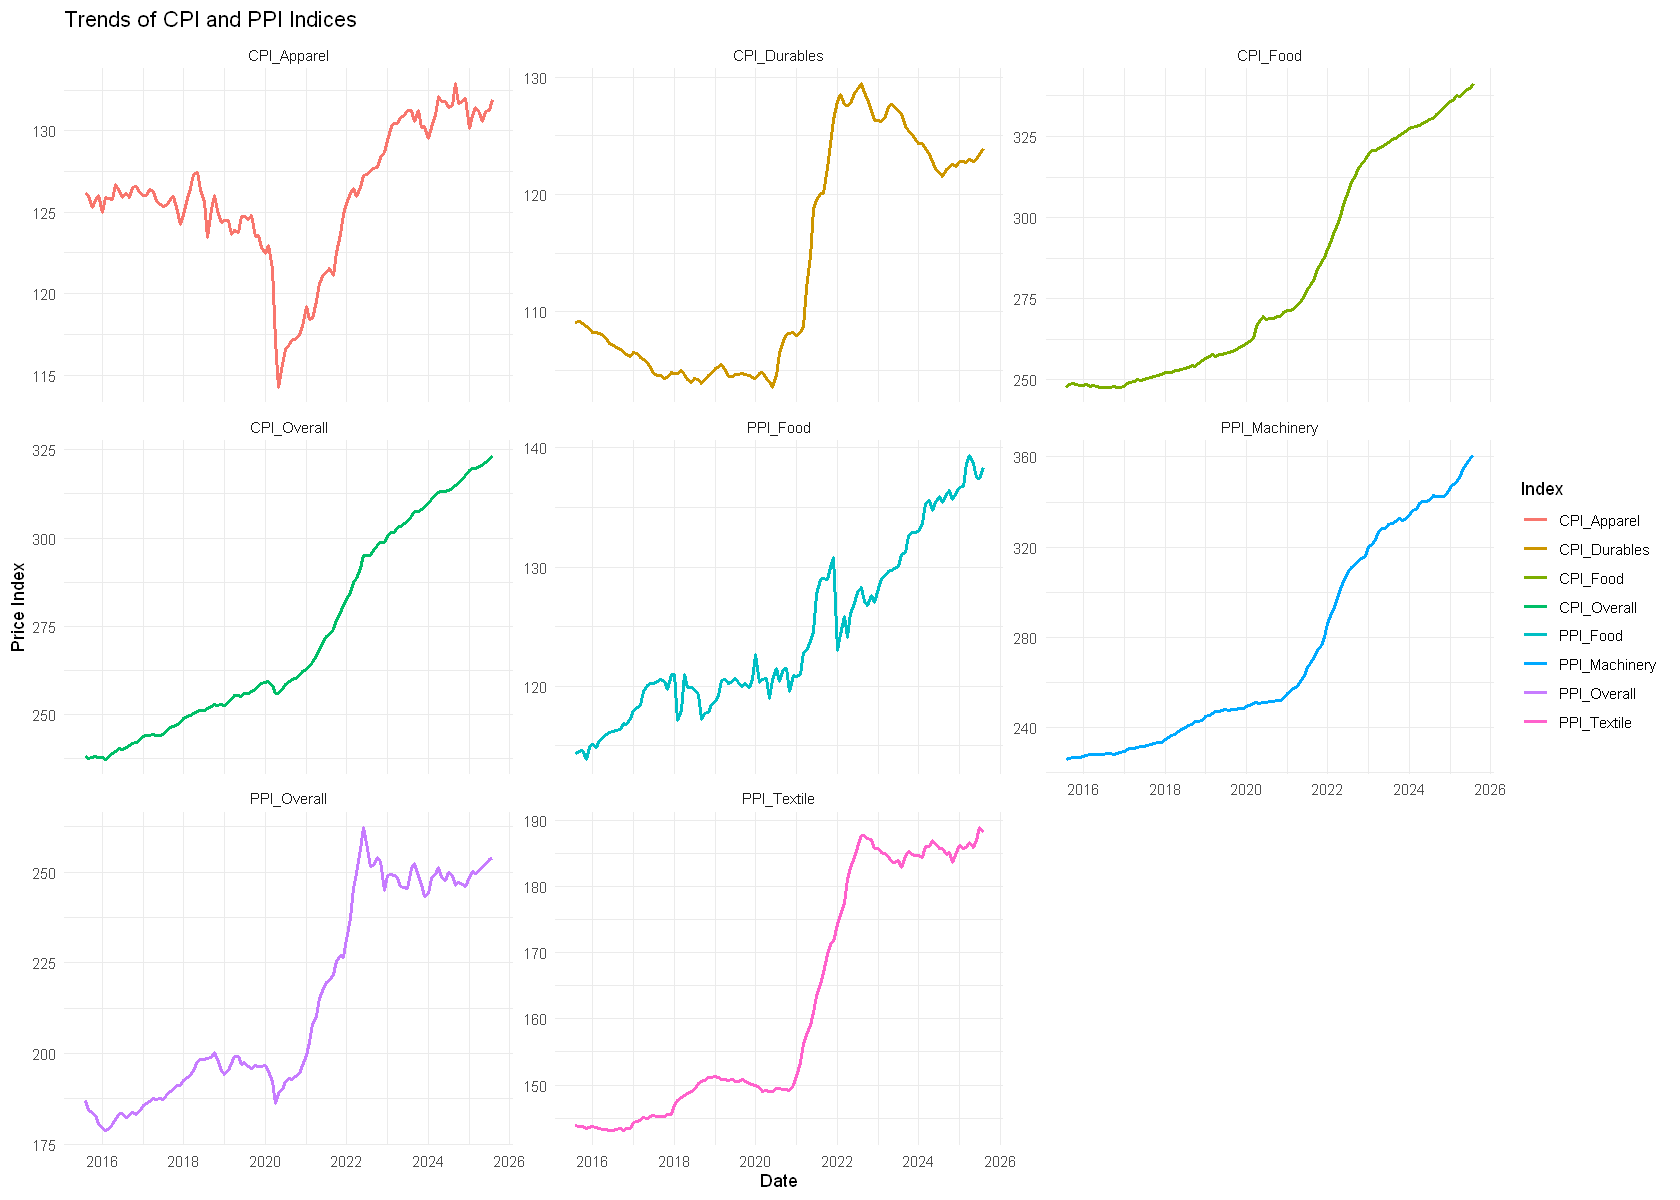

In [5]:
combined_long <- pivot_longer(combined_data, cols = -Date, names_to = "Index", values_to = "Value")

options(repr.plot.width=14, repr.plot.height=10)
ggplot(combined_long, aes(x = Date, y = Value, color = Index)) +
  geom_line(size = 1) +
  facet_wrap(~ Index, scales = "free_y") +
  theme_minimal() +
  labs(title = "Trends of CPI and PPI Indices", x = "Date", y = "Price Index")

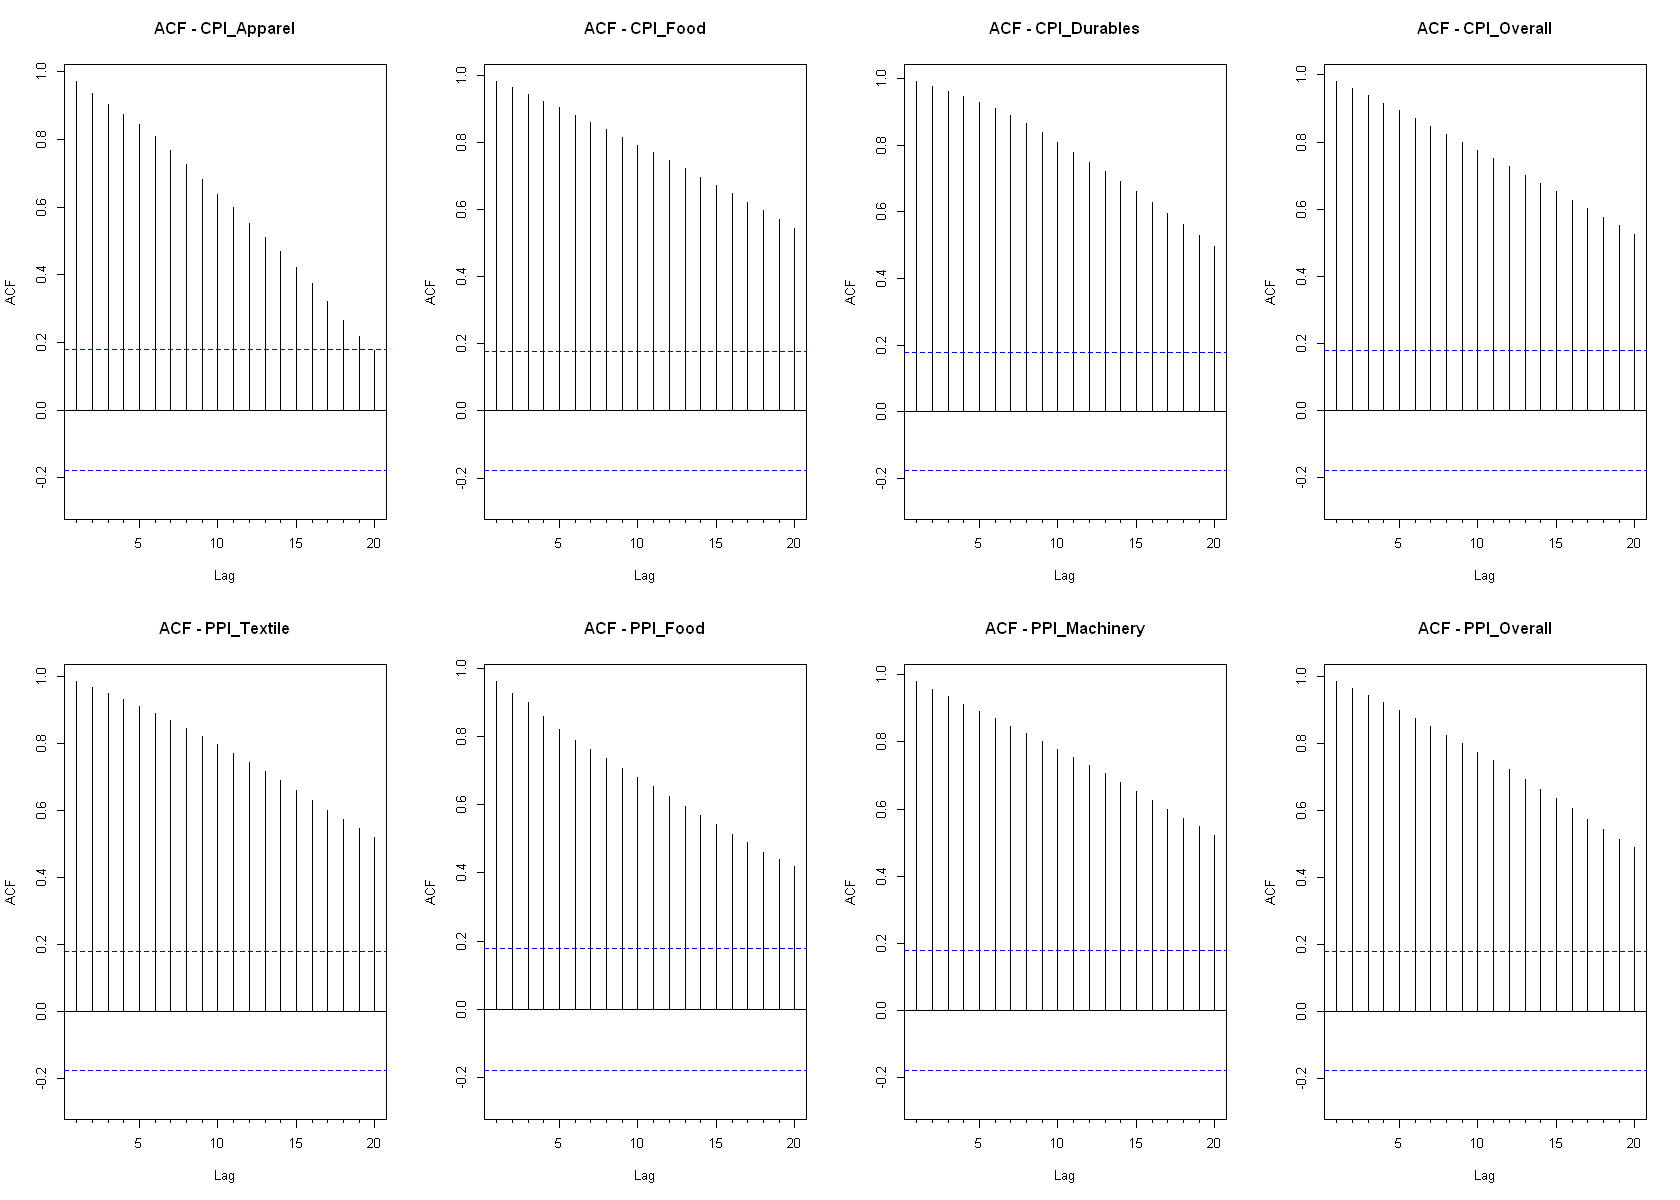

In [6]:
series_names <- colnames(combined_data)[-1]
par(bg = "white")
par(mfrow=c(2,4))

for (name in series_names) {
  Acf(combined_data[[name]], main = paste("ACF -", name))
}

In [7]:
adf_results <- sapply(select(combined_data, -Date),
  function(x) {
    test <- adf.test(x, alternative = "stationary")
    c(statistic = test$statistic, p_value = test$p.value)
  })

adf_results <- t(adf_results)
adf_results <- as.data.frame(adf_results)
adf_results

,statistic.Dickey-Fuller,p_value
,<dbl>,<dbl>
CPI_Apparel,-1.316306,0.8605514
CPI_Food,-2.228079,0.4818294
CPI_Durables,-1.964756,0.5912056
CPI_Overall,-1.621521,0.7337746
PPI_Textile,-2.521774,0.3598377
PPI_Food,-2.060695,0.5513555
PPI_Machinery,-2.000322,0.5764325
PPI_Overall,-1.914398,0.6121227


All of the tests gave a pvalue of P>0.05 so we fail to reject the null hypothesis meaning that all these series are non stationary.

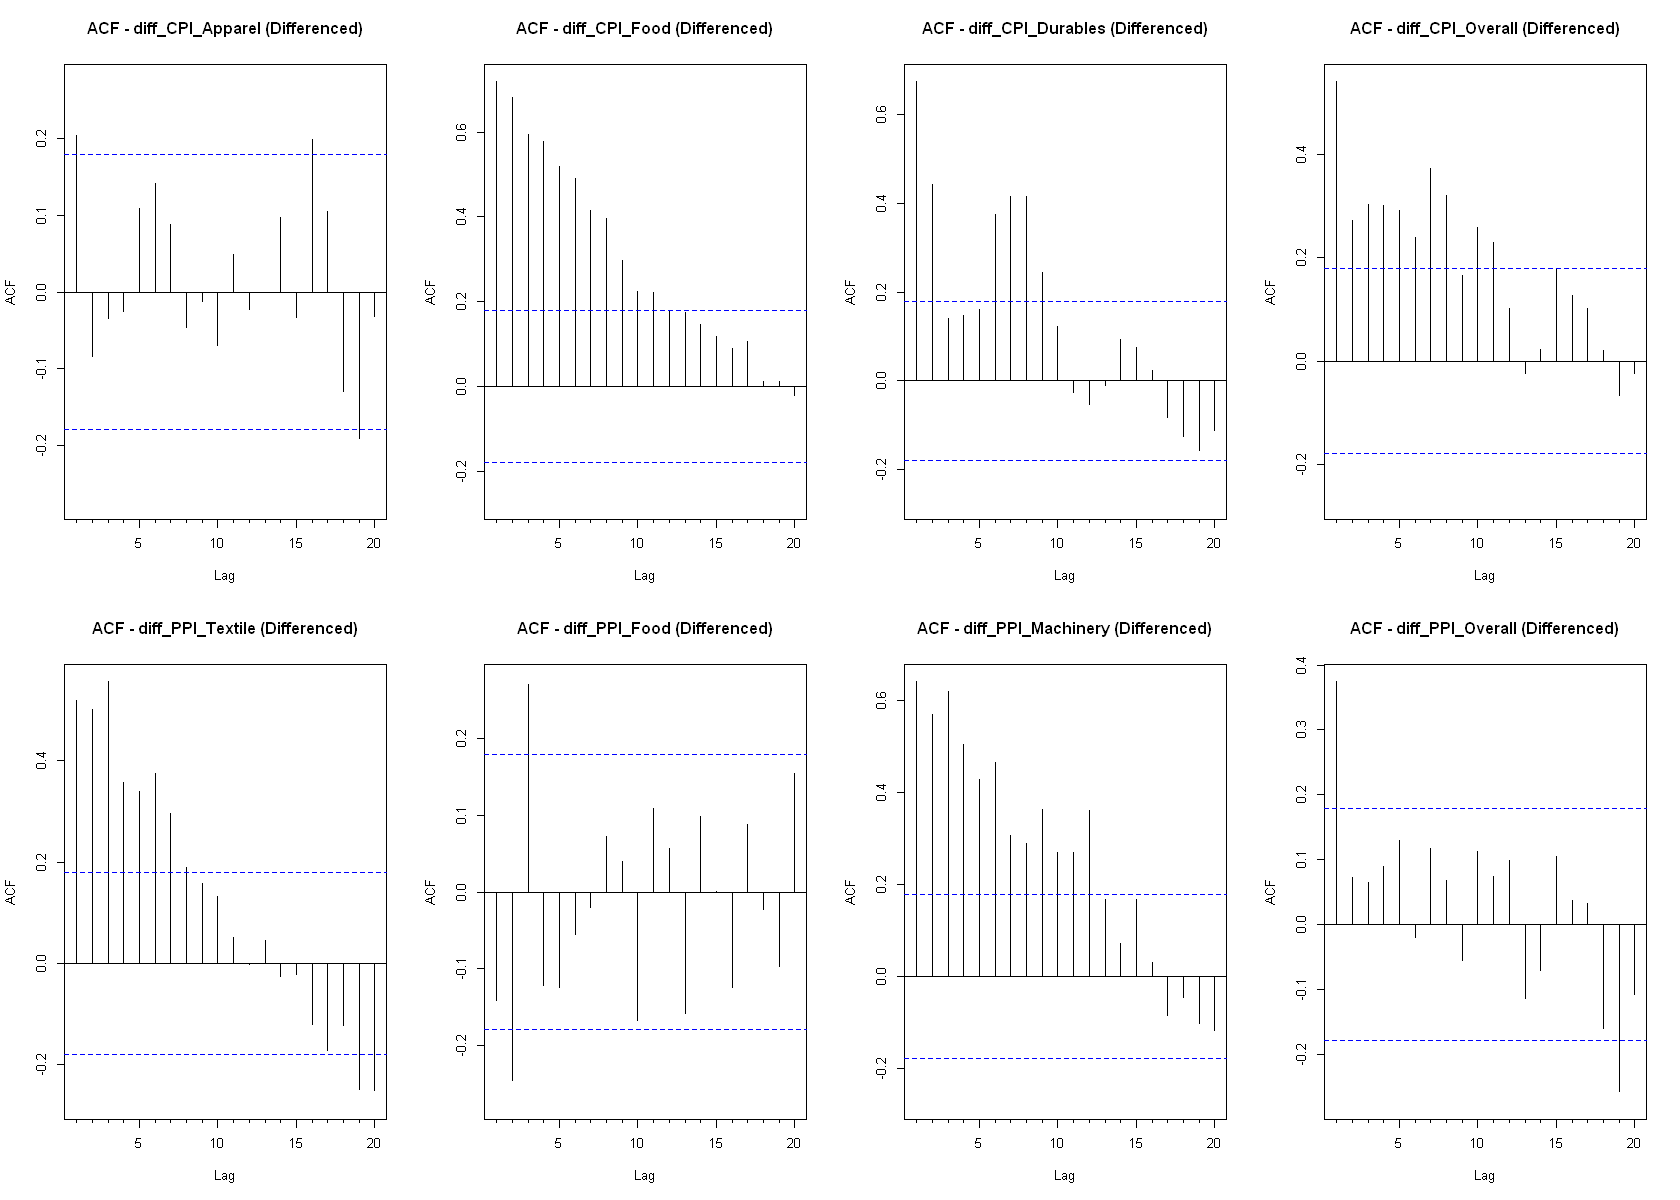

In [8]:
tmp <- arrange(combined_data, Date)
tmp <- mutate(tmp,across(-Date, ~ c(NA, diff(.)), .names = "diff_{.col}"))

diff_data <- drop_na(tmp)

diff_series <- colnames(diff_data)[grep("^diff_", colnames(diff_data))]

par(bg = "white")
par(mfrow=c(2,4))

for (name in diff_series) {
  Acf(diff_data[[name]], main = paste("ACF -", name, "(Differenced)"))
}

In [9]:
adf_diff_results <- lapply(select(diff_data, starts_with("diff_")), adf.test)

adf_diff_summary <- data.frame(
  Series = names(adf_diff_results),
  Statistic = sapply(adf_diff_results, function(x) x$statistic),
  P_Value = sapply(adf_diff_results, function(x) x$p.value)
)

print(adf_diff_summary)

Warning message in FUN(X[[i]], ...):
"p-value smaller than printed p-value"
Warning message in FUN(X[[i]], ...):
"p-value smaller than printed p-value"


                                             Series Statistic    P_Value
diff_CPI_Apparel.Dickey-Fuller     diff_CPI_Apparel -4.307790 0.01000000
diff_CPI_Food.Dickey-Fuller           diff_CPI_Food -2.287327 0.45723800
diff_CPI_Durables.Dickey-Fuller   diff_CPI_Durables -2.982714 0.16842583
diff_CPI_Overall.Dickey-Fuller     diff_CPI_Overall -2.987580 0.16640504
diff_PPI_Textile.Dickey-Fuller     diff_PPI_Textile -2.656503 0.30390982
diff_PPI_Food.Dickey-Fuller           diff_PPI_Food -5.381645 0.01000000
diff_PPI_Machinery.Dickey-Fuller diff_PPI_Machinery -2.528492 0.35707595
diff_PPI_Overall.Dickey-Fuller     diff_PPI_Overall -3.731801 0.02466632


In [10]:
mfn_usa <- select(filter(mfn_tariff, Reporting.Economy == "United States of America"),
  Year, Reporting.Economy, Reporting.Economy.ISO3A.Code, MFN_Tariff = Value)


combined_data <- mutate(combined_data, Year = year(Date))
combined_with_tariff <- left_join(combined_data, mfn_usa, by = "Year")
combined_with_tariff <- select(combined_with_tariff, Reporting.Economy, Reporting.Economy.ISO3A.Code, Date, Year,
  everything())

combined_with_tariff <- arrange(combined_with_tariff, Date)
combined_with_tariff <- fill(combined_with_tariff, MFN_Tariff, .direction = "downup")

head(combined_with_tariff)


,Reporting.Economy,Reporting.Economy.ISO3A.Code,Date,Year,CPI_Apparel,CPI_Food,CPI_Durables,CPI_Overall,PPI_Textile,PPI_Food,PPI_Machinery,PPI_Overall,MFN_Tariff
,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,United States of America,USA,2015-08-01,2015,126.166,247.742,109.057,238.033,143.9,114.4,225.9,187.0,3.48
2,United States of America,USA,2015-09-01,2015,126.011,248.492,109.148,237.498,143.8,114.5,226.0,184.3,3.48
3,United States of America,USA,2015-10-01,2015,125.323,248.755,108.995,237.733,143.7,114.6,226.4,183.7,3.48
4,United States of America,USA,2015-11-01,2015,125.724,248.525,108.765,238.017,143.5,113.9,226.4,182.9,3.48
5,United States of America,USA,2015-12-01,2015,126.042,248.206,108.539,237.761,143.6,114.9,226.5,180.8,3.48
6,United States of America,USA,2016-01-01,2016,124.999,248.353,108.232,237.652,143.8,115.1,227.1,179.7,3.48


In [11]:
tail(combined_with_tariff['MFN_Tariff'])

,MFN_Tariff
,<dbl>
116,3.341207
117,3.341207
118,3.341207
119,3.341207
120,3.341207
121,3.341207


In [12]:
numeric_data <- select(combined_with_tariff,
  CPI_Apparel, CPI_Food, CPI_Durables, CPI_Overall,
  PPI_Textile, PPI_Food, PPI_Machinery, PPI_Overall,
  MFN_Tariff)

cor_matrix <- cor(numeric_data, use = "complete.obs")
round(cor_matrix, 2)

,CPI_Apparel,CPI_Food,CPI_Durables,CPI_Overall,PPI_Textile,PPI_Food,PPI_Machinery,PPI_Overall,MFN_Tariff
CPI_Apparel,1.00,0.64,0.59,0.63,0.65,0.60,0.66,0.63,-0.36
CPI_Food,0.64,1.00,0.88,0.99,0.97,0.95,1.00,0.96,-0.77
CPI_Durables,0.59,0.88,1.00,0.87,0.94,0.80,0.87,0.94,-0.64
CPI_Overall,0.63,0.99,0.87,1.00,0.98,0.96,1.00,0.96,-0.80
PPI_Textile,0.65,0.97,0.94,0.98,1.00,0.92,0.97,0.99,-0.78
PPI_Food,0.60,0.95,0.80,0.96,0.92,1.00,0.96,0.90,-0.74
PPI_Machinery,0.66,1.00,0.87,1.00,0.97,0.96,1.00,0.96,-0.79
PPI_Overall,0.63,0.96,0.94,0.96,0.99,0.90,0.96,1.00,-0.78
MFN_Tariff,-0.36,-0.77,-0.64,-0.80,-0.78,-0.74,-0.79,-0.78,1.00


In [13]:
safe_log <- function(x) log(x + 1e-8)


cpi_cols <- c("CPI_Apparel", "CPI_Food", "CPI_Durables", "CPI_Overall")
ppi_cols <- c("PPI_Textile", "PPI_Food", "PPI_Machinery", "PPI_Overall")
tariff_col <- "MFN_Tariff"

combined_with_tariff <- mutate(combined_with_tariff,
across(all_of(c(cpi_cols, ppi_cols, tariff_col)), as.numeric))

combined_with_tariff <- arrange(combined_with_tariff, Date)
combined_with_tariff <- mutate(
  combined_with_tariff,
  across(all_of(cpi_cols), ~ safe_log(.x), .names = "log_{.col}"),
  across(all_of(ppi_cols), ~ safe_log(.x), .names = "log_{.col}"),
  log_MFN = safe_log(combined_with_tariff[[tariff_col]]))

combined_with_tariff <- mutate(
  combined_with_tariff,
  across(starts_with("log_CPI"), ~ c(NA, diff(.x)), .names = "d_{.col}"),
  across(starts_with("log_PPI"), ~ c(NA, diff(.x)), .names = "d_{.col}"),
  d_log_MFN = c(NA, diff(log_MFN)))

combined_with_tariff <- rename_with(
  combined_with_tariff,
  .fn = ~ sub("^d_log_CPI_", "dlog_CPI_", .x),
  .cols = starts_with("d_log_CPI_"))

combined_with_tariff <- rename_with(
  combined_with_tariff,
  .fn = ~ sub("^d_log_PPI_", "dlog_PPI_", .x),
  .cols = starts_with("d_log_PPI_"))

summary(select(combined_with_tariff, Date, starts_with("dlog_"), d_log_MFN))

      Date            dlog_CPI_Apparel     dlog_CPI_Food       
 Min.   :2015-08-01   Min.   :-0.0376622   Min.   :-0.0037949  
 1st Qu.:2018-02-01   1st Qu.:-0.0022676   1st Qu.: 0.0008711  
 Median :2020-08-01   Median : 0.0009717   Median : 0.0019290  
 Mean   :2020-07-31   Mean   : 0.0003711   Mean   : 0.0026675  
 3rd Qu.:2023-02-01   3rd Qu.: 0.0047455   3rd Qu.: 0.0036425  
 Max.   :2025-08-01   Max.   : 0.0136128   Max.   : 0.0141706  
                      NA's   :1            NA's   :1           
 dlog_CPI_Durables    dlog_CPI_Overall     dlog_PPI_Textile    
 Min.   :-0.0086830   Min.   :-0.0079517   Min.   :-0.0082420  
 1st Qu.:-0.0024608   1st Qu.: 0.0009056   1st Qu.:-0.0009852  
 Median :-0.0004978   Median : 0.0023384   Median : 0.0006671  
 Mean   : 0.0010643   Mean   : 0.0025531   Mean   : 0.0022351  
 3rd Qu.: 0.0025860   3rd Qu.: 0.0038278   3rd Qu.: 0.0046990  
 Max.   : 0.0337174   Max.   : 0.0128692   Max.   : 0.0201229  
 NA's   :1            NA's   :1         

In [14]:
stationarity_cols <- select(combined_with_tariff, starts_with("dlog_"), d_log_MFN)
run_adf <- function(series) {
  x <- as.numeric(series)
  x <- x[!is.na(x)] 
  test <- adf.test(x, alternative = "stationary")

  return(c(
    statistic = unname(test$statistic),
    p_value   = test$p.value
  ))
}

adf_results <- t(apply(stationarity_cols, 2, run_adf))
adf_results <- as.data.frame(adf_results)
adf_results


Warning message in adf.test(x, alternative = "stationary"):
"p-value smaller than printed p-value"
Warning message in adf.test(x, alternative = "stationary"):
"p-value smaller than printed p-value"
Warning message in adf.test(x, alternative = "stationary"):
"p-value smaller than printed p-value"


,statistic,p_value
,<dbl>,<dbl>
dlog_CPI_Apparel,-4.295420,0.01000000
dlog_CPI_Food,-2.316472,0.44513347
dlog_CPI_Durables,-3.032811,0.14761930
dlog_CPI_Overall,-3.024910,0.15090107
dlog_PPI_Textile,-2.589170,0.33187495
dlog_PPI_Food,-5.374179,0.01000000
dlog_PPI_Machinery,-2.389178,0.41493671
dlog_PPI_Overall,-3.737614,0.02438392
d_log_MFN,-4.784537,0.01000000


In [15]:
non_stationary_series <- c(
  "dlog_CPI_Food",
  "dlog_CPI_Durables",
  "dlog_CPI_Overall",
  "dlog_PPI_Textile",
  "dlog_PPI_Machinery")

combined_with_tariff <- arrange(combined_with_tariff, Date)
combined_with_tariff <- mutate(
  combined_with_tariff,
  across(all_of(non_stationary_series), ~ c(NA, diff(.)), .names = "d2_{.col}"))

summary(select(combined_with_tariff, Date, starts_with("d2_")))
d2_cols <- c("d2_dlog_CPI_Food", "d2_dlog_CPI_Durables",
             "d2_dlog_CPI_Overall", "d2_dlog_PPI_Textile", "d2_dlog_PPI_Machinery")

adf_d2_results <- lapply(d2_cols, function(col) {
  series <- na.omit(combined_with_tariff[[col]])
  adf.test(series)
})

adf_d2_summary <- data.frame(
  Series = d2_cols,
  Statistic = sapply(adf_d2_results, function(x) x$statistic),
  P_Value = sapply(adf_d2_results, function(x) x$p.value))
print(adf_d2_summary)


      Date            d2_dlog_CPI_Food     d2_dlog_CPI_Durables
 Min.   :2015-08-01   Min.   :-0.0092522   Min.   :-0.0266061  
 1st Qu.:2018-02-01   1st Qu.:-0.0012492   1st Qu.:-0.0027129  
 Median :2020-08-01   Median : 0.0000311   Median : 0.0000324  
 Mean   :2020-07-31   Mean   : 0.0000130   Mean   : 0.0000281  
 3rd Qu.:2023-02-01   3rd Qu.: 0.0010856   3rd Qu.: 0.0020511  
 Max.   :2025-08-01   Max.   : 0.0116543   Max.   : 0.0241337  
                      NA's   :2            NA's   :2           
 d2_dlog_CPI_Overall  d2_dlog_PPI_Textile  d2_dlog_PPI_Machinery
 Min.   :-0.0133166   Min.   :-0.0142040   Min.   :-0.0100553   
 1st Qu.:-0.0013945   1st Qu.:-0.0022341   1st Qu.:-0.0017635   
 Median : 0.0002477   Median :-0.0000019   Median :-0.0000007   
 Mean   : 0.0000510   Mean   :-0.0000275   Mean   : 0.0000230   
 3rd Qu.: 0.0014030   3rd Qu.: 0.0027581   3rd Qu.: 0.0017152   
 Max.   : 0.0070529   Max.   : 0.0158357   Max.   : 0.0111351   
 NA's   :2            NA's   :2  

Warning message in adf.test(series):
"p-value smaller than printed p-value"
Warning message in adf.test(series):
"p-value smaller than printed p-value"
Warning message in adf.test(series):
"p-value smaller than printed p-value"
Warning message in adf.test(series):
"p-value smaller than printed p-value"
Warning message in adf.test(series):
"p-value smaller than printed p-value"


                 Series Statistic P_Value
1      d2_dlog_CPI_Food -6.278094    0.01
2  d2_dlog_CPI_Durables -9.301182    0.01
3   d2_dlog_CPI_Overall -7.041832    0.01
4   d2_dlog_PPI_Textile -6.457835    0.01
5 d2_dlog_PPI_Machinery -6.355550    0.01


In [16]:
cpi_series <- list(
  dlog_CPI_Apparel = 1,
  d2_dlog_CPI_Food = 2,
  d2_dlog_CPI_Durables = 2,
  d2_dlog_CPI_Overall = 2
)

top_bic_models <- list()

for(dep_var in names(cpi_series)) {
  d_val <- cpi_series[[dep_var]]
  
  model_data <- na.omit(select(combined_with_tariff, all_of(c(dep_var, "d_log_MFN"))))
  
  y <- model_data[[dep_var]]
  xreg <- model_data[["d_log_MFN"]]
  
  pdq_grid <- expand.grid(p = 0:6, d = d_val, q = 0:6)
  
  bic_results <- data.frame()
  
  for(i in 1:nrow(pdq_grid)) {
    params <- pdq_grid[i, ]
    fit <- try(arima(y, order = c(params$p, params$d, params$q), xreg = xreg), silent = TRUE)
    
    if(!inherits(fit, "try-error")) {
      bic_results <- rbind(bic_results,
                           data.frame(p = params$p, d = params$d, q = params$q,
                                      BIC = BIC(fit)))
    }
  }

  top_bic_models[[dep_var]] <- bic_results %>%
    arrange(BIC) %>%
    head(5)
}

top_bic_models


Warning message in log(s2):
"NaNs produced"
Warning message in arima(y, order = c(params$p, params$d, params$q), xreg = xreg):
"possible convergence problem: optim gave code = 1"
Warning message in arima(y, order = c(params$p, params$d, params$q), xreg = xreg):
"possible convergence problem: optim gave code = 1"
Warning message in arima(y, order = c(params$p, params$d, params$q), xreg = xreg):
"possible convergence problem: optim gave code = 1"
Warning message in log(s2):
"NaNs produced"
Warning message in log(s2):
"NaNs produced"
Warning message in log(s2):
"NaNs produced"
Warning message in log(s2):
"NaNs produced"
Warning message in log(s2):
"NaNs produced"
Warning message in log(s2):
"NaNs produced"
Warning message in log(s2):
"NaNs produced"


,p,d,q,BIC
,<int>,<dbl>,<int>,<dbl>
1,0,1,2,-829.6900
2,1,1,1,-827.9743
3,0,1,1,-826.8788
4,1,1,2,-826.0174
5,0,1,3,-825.7487
,p,d,q,BIC
,<int>,<dbl>,<int>,<dbl>
1,0,2,3,-1064.404
2,1,2,2,-1061.550


In [17]:
combine_coefs <- function(coef_list) {
  all_names <- unique(unlist(lapply(coef_list, names)))
  df_list <- lapply(names(coef_list), function(nm) {
    coefs <- coef_list[[nm]]
    for(n in setdiff(all_names, names(coefs))) coefs[n] <- NA
    data.frame(Model = nm, t(coefs))
  })
  do.call(rbind, df_list)
}

fitted_models <- list()
coef_summary <- list()

for(dep_var in names(top_bic_models)) {
  model_data <- na.omit(select(combined_with_tariff, all_of(c(dep_var, "d_log_MFN"))))
  
  y <- model_data[[dep_var]]
  xreg <- model_data[["d_log_MFN"]]
  
  coef_list <- list()
  
  for(i in 1:nrow(top_bic_models[[dep_var]])) {
    row <- top_bic_models[[dep_var]][i, ]
    fit <- arima(y, order = c(row$p, row$d, row$q), xreg = xreg)
    coef_list[[paste0("model_", i)]] <- coef(fit)
  }
  
  fitted_models[[dep_var]] <- coef_list
  coef_summary[[dep_var]] <- combine_coefs(coef_list)
}

coef_summary


$dlog_CPI_Apparel
    Model        ma1        ma2         xreg        ar1        ma3
1 model_1 -0.7055114 -0.2839673 -0.028221331         NA         NA
2 model_2 -0.9930691         NA -0.046707521  0.2282760         NA
3 model_3 -0.9570049         NA -0.055035097         NA         NA
4 model_4 -0.2305937 -0.7337881  0.003938029 -0.5064034         NA
5 model_5 -0.7212496 -0.3504737 -0.005964546         NA 0.09420724

$d2_dlog_CPI_Food
    Model       ma1       ma2        ma3         xreg         ar1        ma4
1 model_1 -2.487392 1.9764710 -0.4886196 -0.004528168          NA         NA
2 model_2 -1.996828 0.9984518         NA -0.014676045 -0.40673870         NA
3 model_3 -2.475510 1.9595684 -0.4880980 -0.004711615          NA 0.00458248
4 model_4 -2.451461 1.9078349 -0.4558304 -0.005828508 -0.03228975         NA
5 model_5 -1.998367 0.9996978         NA -0.013382758 -0.44231177         NA
          ar2
1          NA
2          NA
3          NA
4          NA
5 -0.08421757

$d2_dlog_CPI_Durables
    Model         ar1         ar2        ar3        ar4        ar5       ma1
1 model_1 -0.19979070 -0.11662083 -0.4432690 -0.1968137 -0.3179666 -1.995112
2 model_2  0.35743830  0.08947531 -0.4851941         NA         NA -2.572212
3 model_3 -0.05548552  0.05212258 -0.4461835         NA         NA -1.998329
4 model_4 -0.23588335 -0.14034712 -0.4774811 -0.2155073 -0.3404547 -1.983510
5 model_5 -0.02769908 -0.09392547 -0.4508291 -0.1243560 -0.3089292 -2.180383
        ma2         xreg        ma3         ar6
1 0.9955254 -0.027051392         NA          NA
2 2.1762241  0.008209982 -0.6038753          NA
3 0.9995367 -0.120872757         NA          NA
4 0.9836437 -0.005402215         NA -0.07236926
5 1.3865712 -0.006954144 -0.2060815          NA

$d2_dlog_CPI_Overall
    Model        ma1        ma2        ma3        ma4         xreg        ar1
1 model_1 -2.2308766  1.0951290  0.5504049 -0.4143305 -0.008217797         NA
2 model_2 -1.9775848  0.3850319  1.1753966 -0.5826240  0.008228416 -0.3731410
3 model_3 -2.2889005  1.1438988  0.7297762 -0.7021418  0.001358427         NA
4 model_4 -2.6761730  2.3836190 -0.7074103         NA -0.033053114  0.3346964
5 model_5 -0.5826195 -1.7045531  0.1415340  1.6977269  0.028145639 -1.6491828
         ma5        ar2        ma6
1         NA         NA         NA
2         NA         NA         NA
3  0.1176398         NA         NA
4         NA -0.2706183         NA
5 -0.0702536 -0.9993440 -0.4813952

In [18]:
mfn_effects <- lapply(coef_summary, function(df) {
  mutate(
    select(df, Model, xreg),
    xreg = as.numeric(xreg)
    )})

mfn_table <- bind_rows(
  lapply(names(mfn_effects), function(name) {
    df <- mfn_effects[[name]]
    mutate(df, CPI = name)
  }))

mfn_table <- select(mfn_table, CPI, everything())
mfn_table


CPI,Model,xreg
<chr>,<chr>,<dbl>
dlog_CPI_Apparel,model_1,-0.028221331
dlog_CPI_Apparel,model_2,-0.046707521
dlog_CPI_Apparel,model_3,-0.055035097
dlog_CPI_Apparel,model_4,0.003938029
dlog_CPI_Apparel,model_5,-0.005964546
d2_dlog_CPI_Food,model_1,-0.004528168
d2_dlog_CPI_Food,model_2,-0.014676045
d2_dlog_CPI_Food,model_3,-0.004711615
d2_dlog_CPI_Food,model_4,-0.005828508


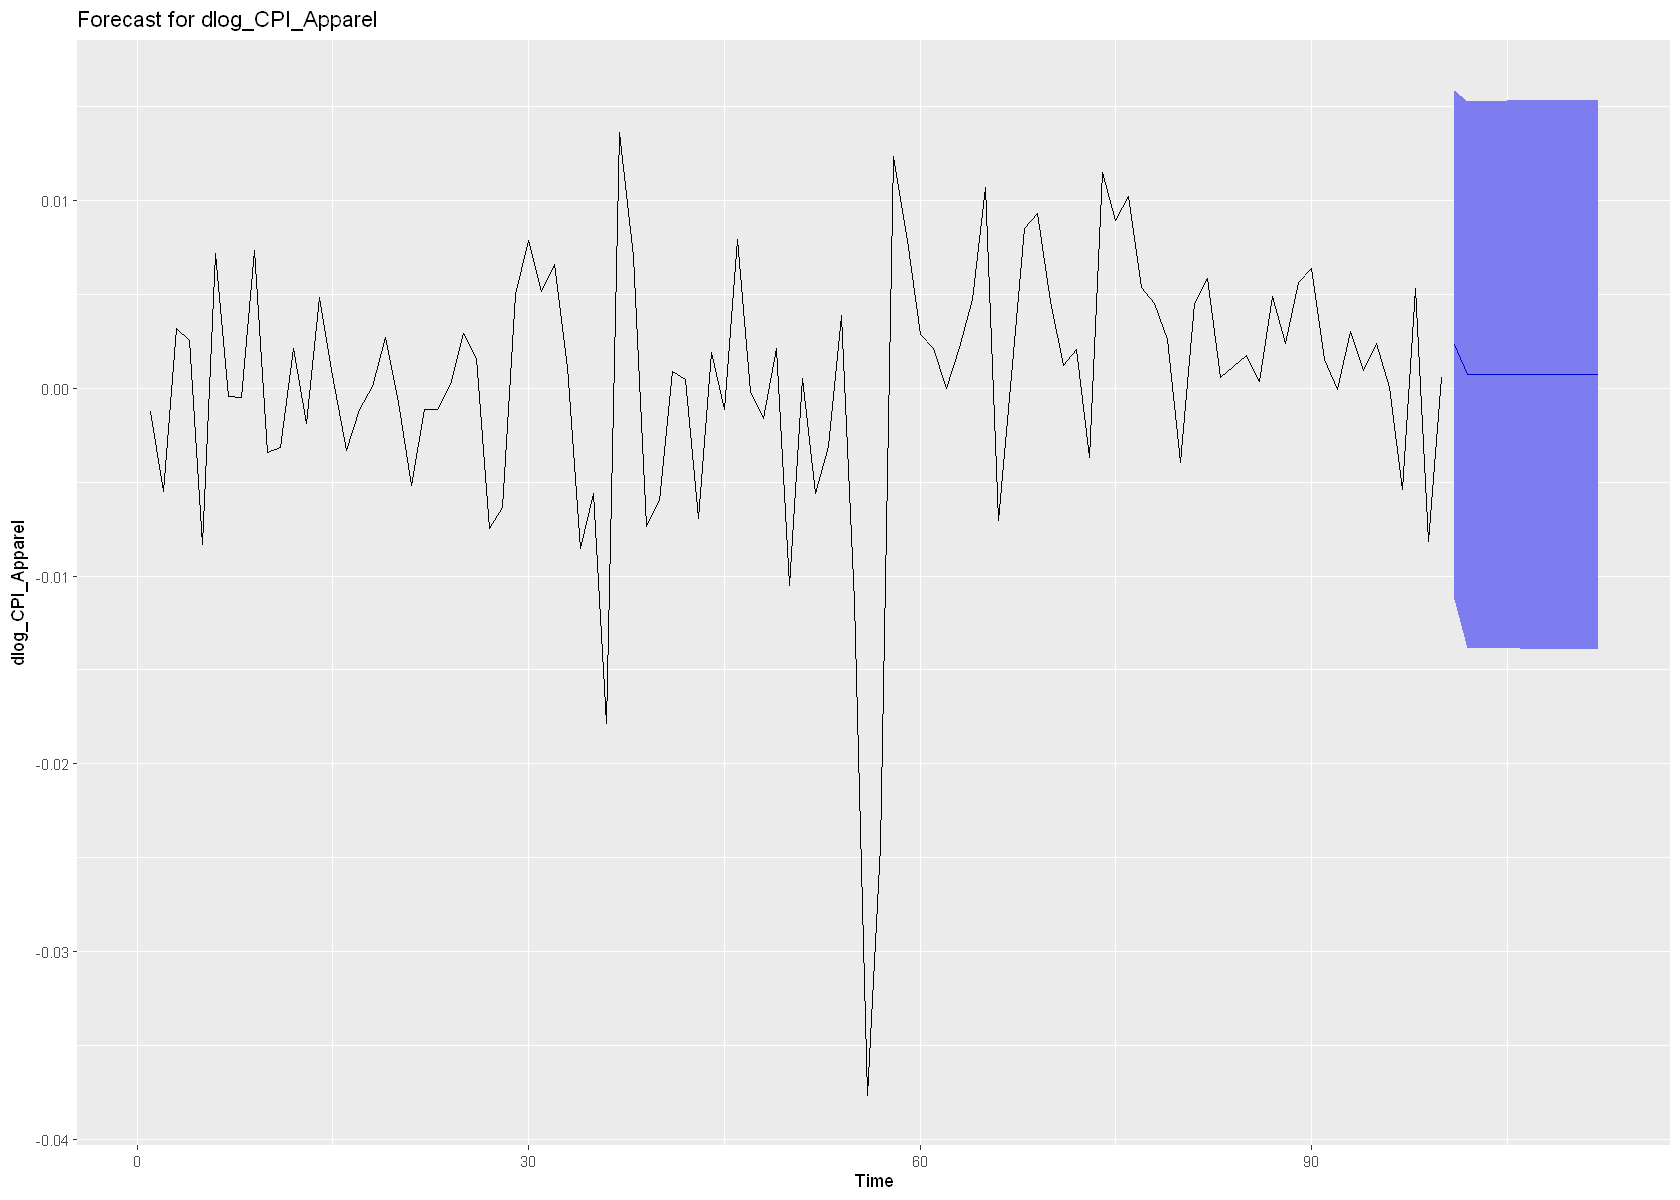

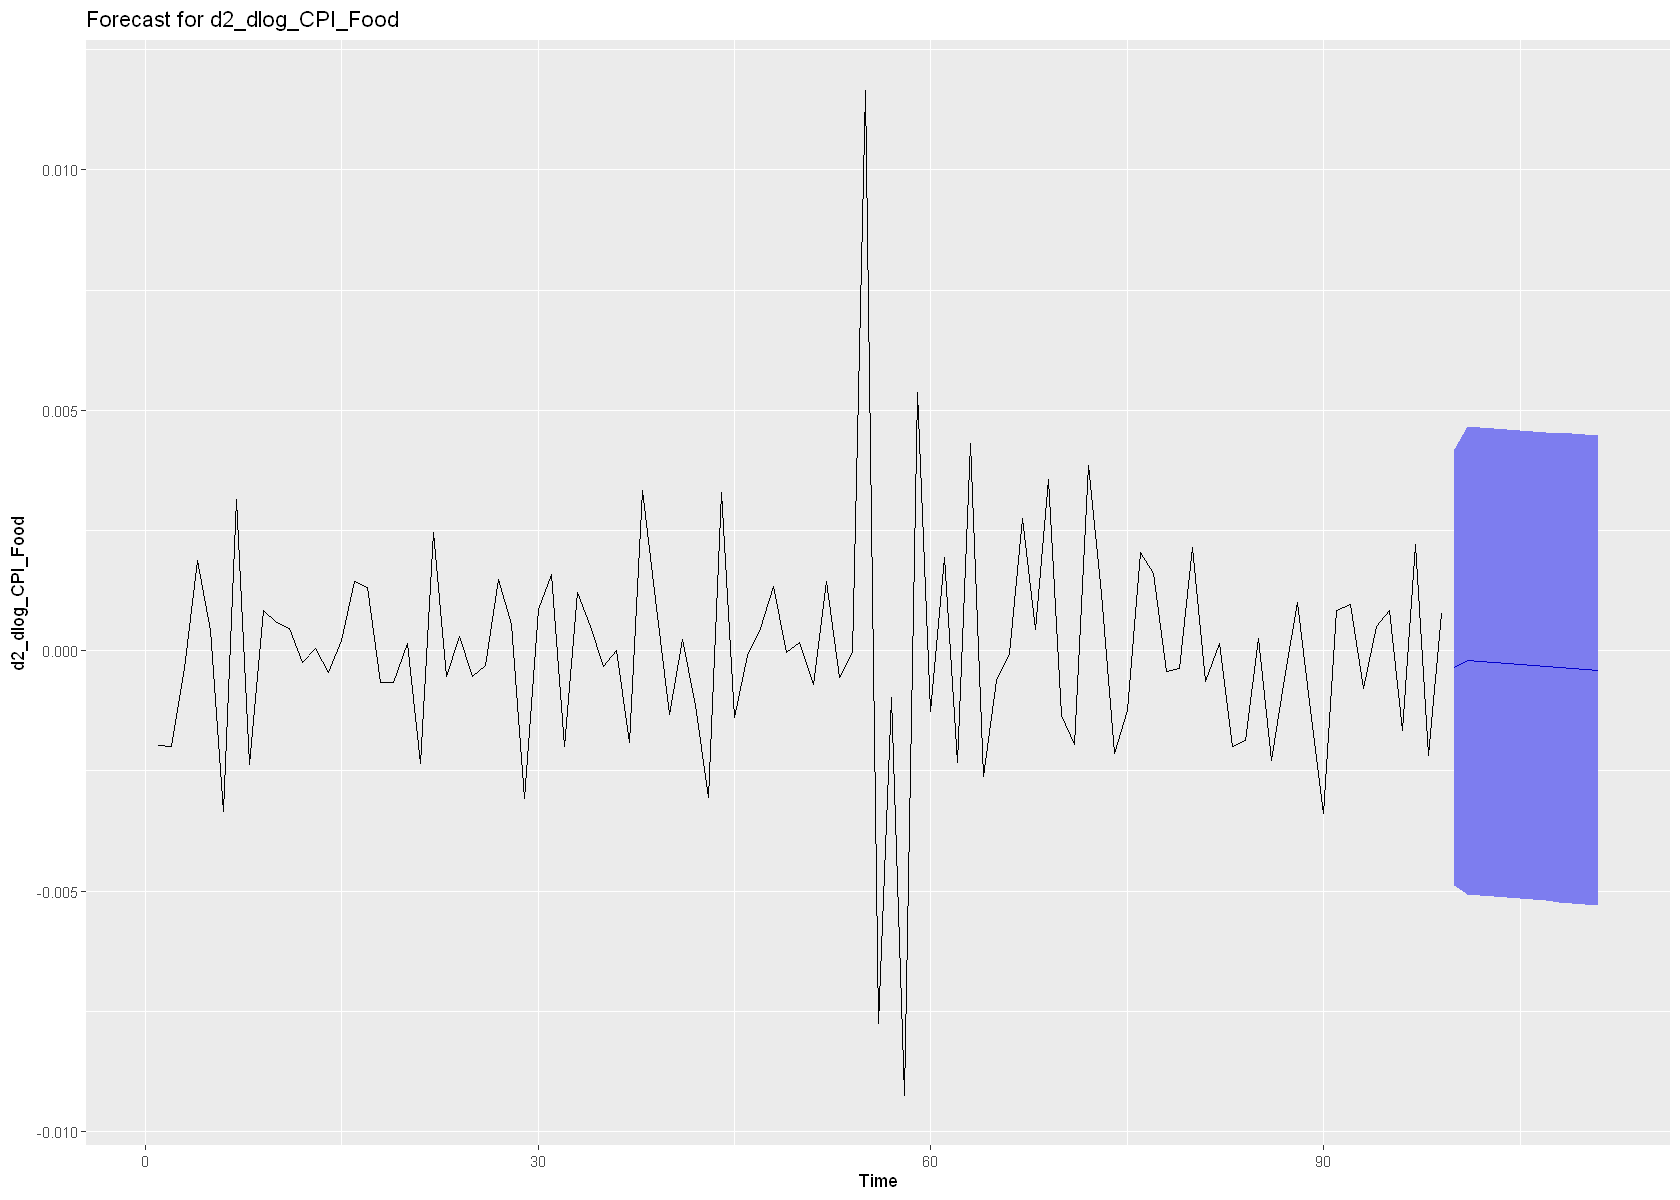

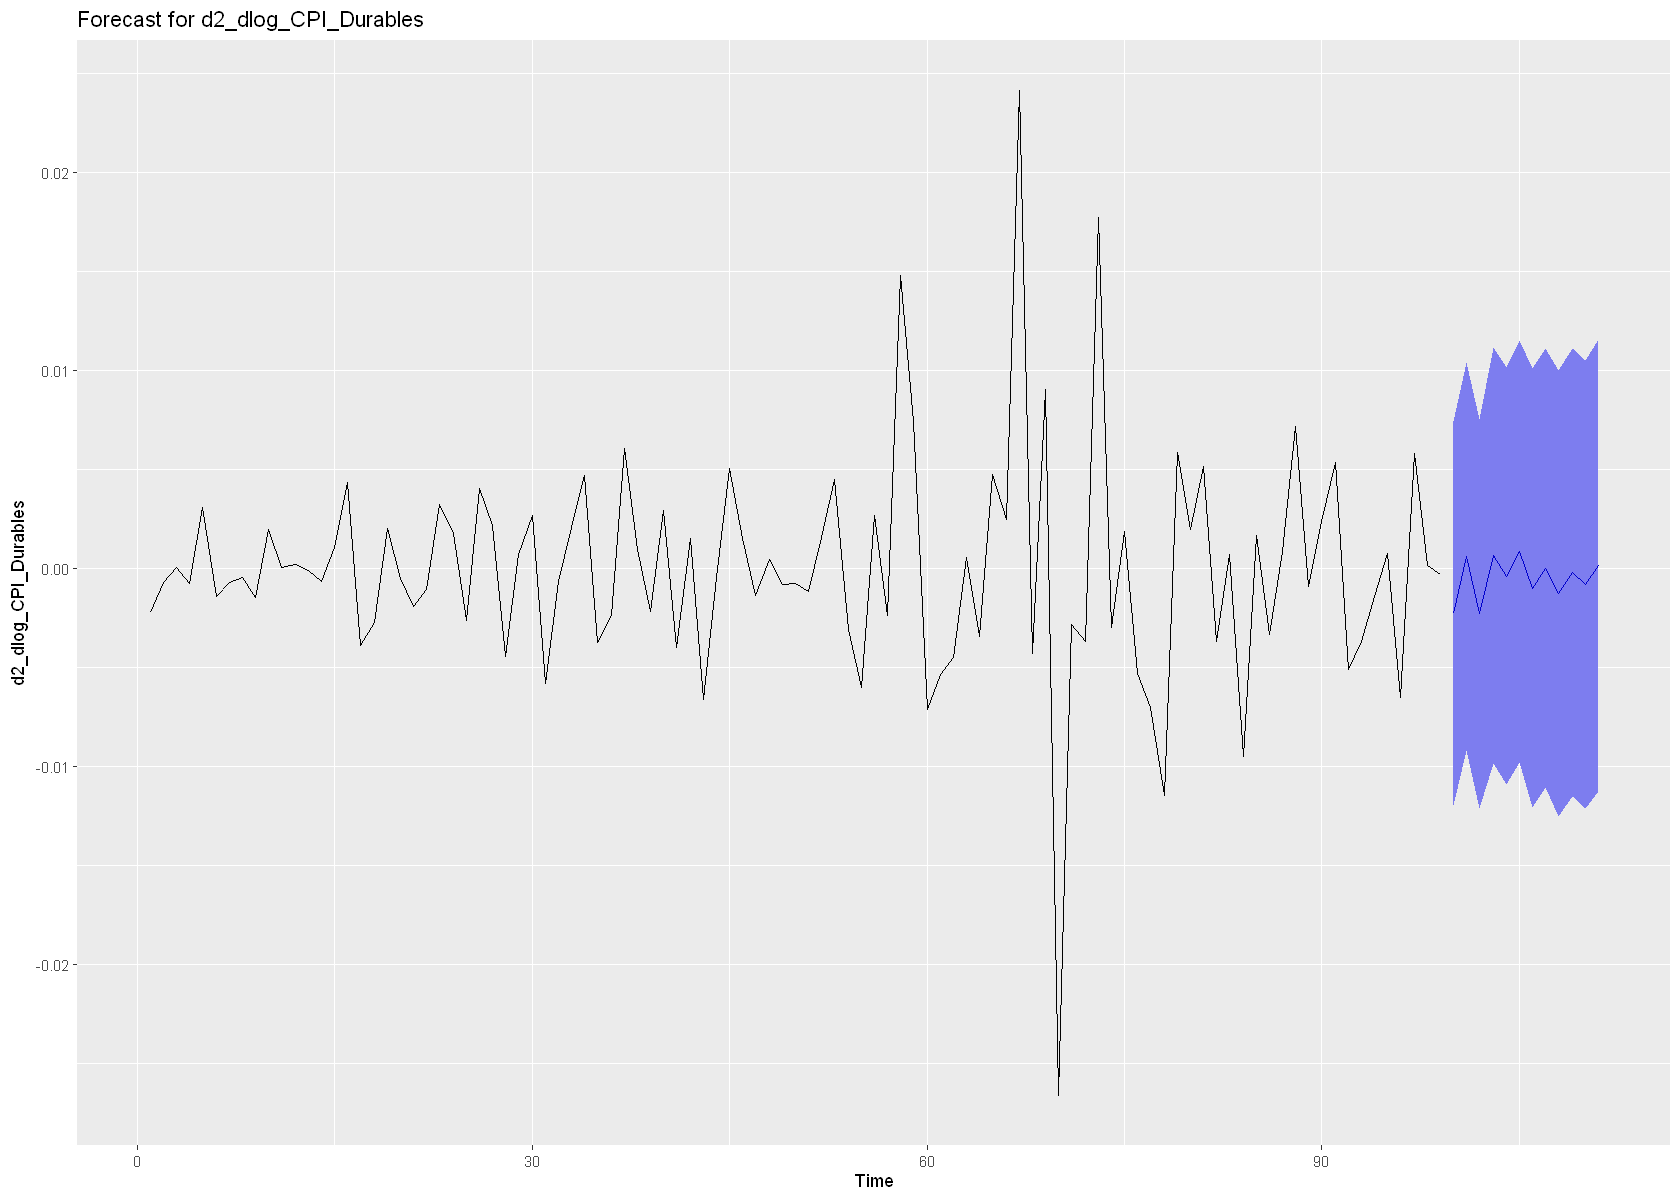

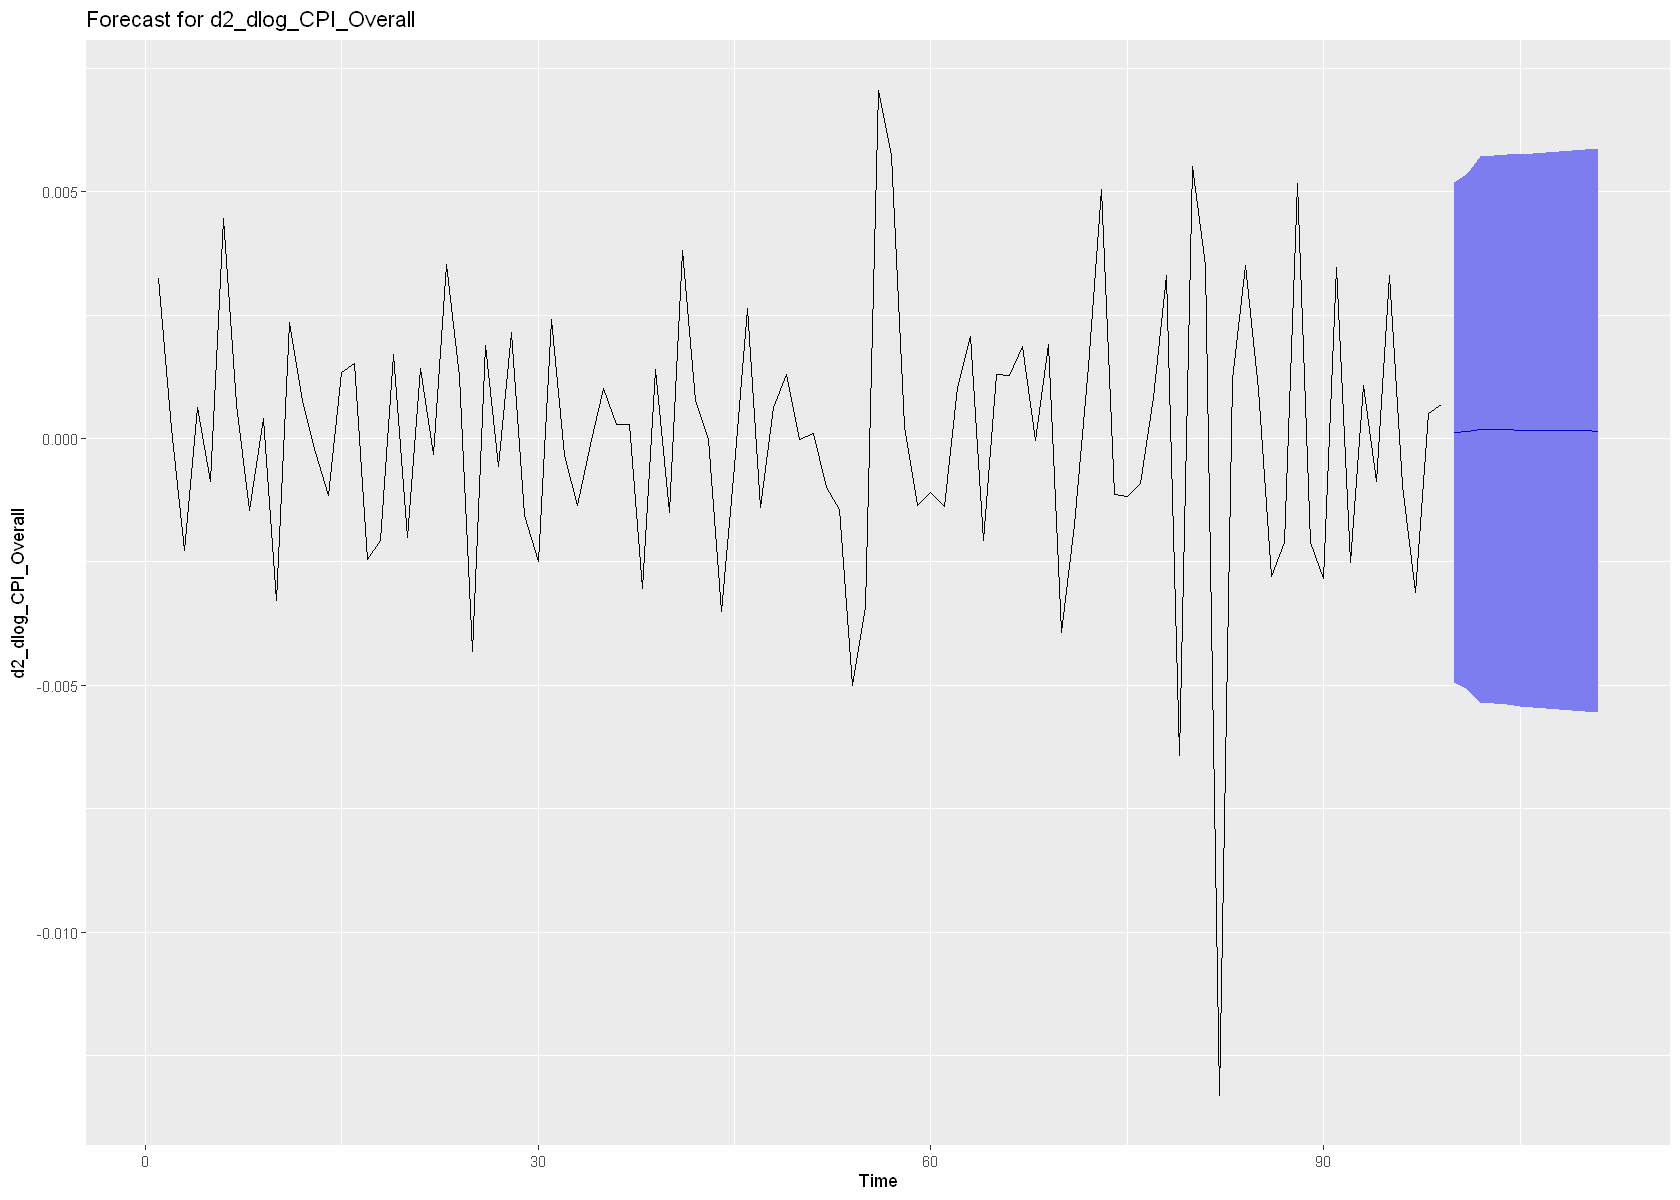

In [19]:
train_data <- filter(combined_with_tariff, Year <= 2023)
test_data  <- filter(combined_with_tariff, Year == 2024)

best_models <- list(
  dlog_CPI_Apparel     = c(0,1,2),
  d2_dlog_CPI_Food     = c(0,2,3),
  d2_dlog_CPI_Durables = c(5,2,2),
  d2_dlog_CPI_Overall  = c(0,2,4)
)

h <- nrow(test_data)
forecast_results <- list()
forecast_plots <- list()

for (cpi_var in names(best_models)) {
  
  p <- best_models[[cpi_var]][1]
  d <- best_models[[cpi_var]][2]
  q <- best_models[[cpi_var]][3]
  
  y_train <- train_data[[cpi_var]]
  x_train <- train_data$d_log_MFN
  
  valid_idx <- which(!is.na(y_train) & !is.na(x_train))
  y_train <- y_train[valid_idx]
  x_train <- x_train[valid_idx]
  
  fit <- Arima(y_train, order = c(p,d,q), xreg = x_train)
  
  x_future <- test_data$d_log_MFN
  fc <- forecast(fit, xreg = x_future, h = h, level = 95)
  
  forecast_results[[cpi_var]] <- fc
  
  p1 <- autoplot(fc) +
    ggtitle(paste("Forecast for", cpi_var)) +
    xlab("Time") + ylab(cpi_var)
  
  print(p1)
  forecast_plots[[cpi_var]] <- p1
}


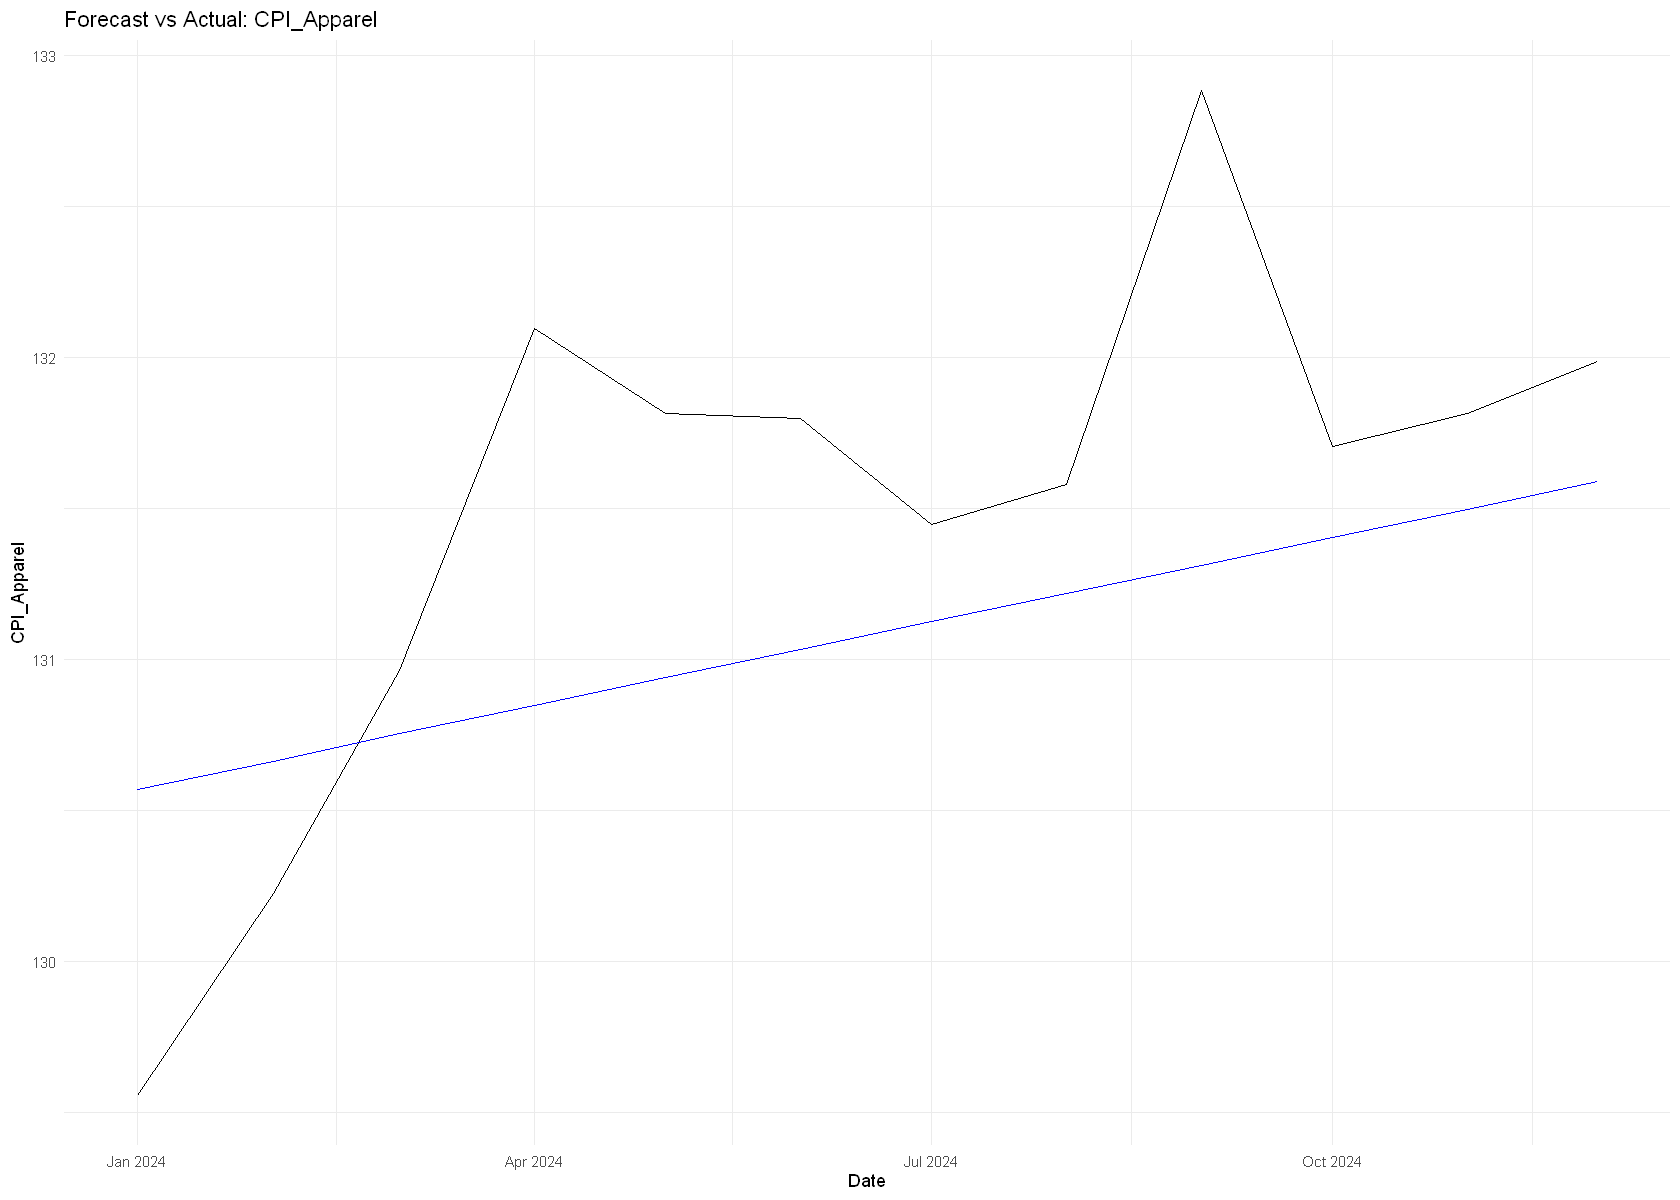

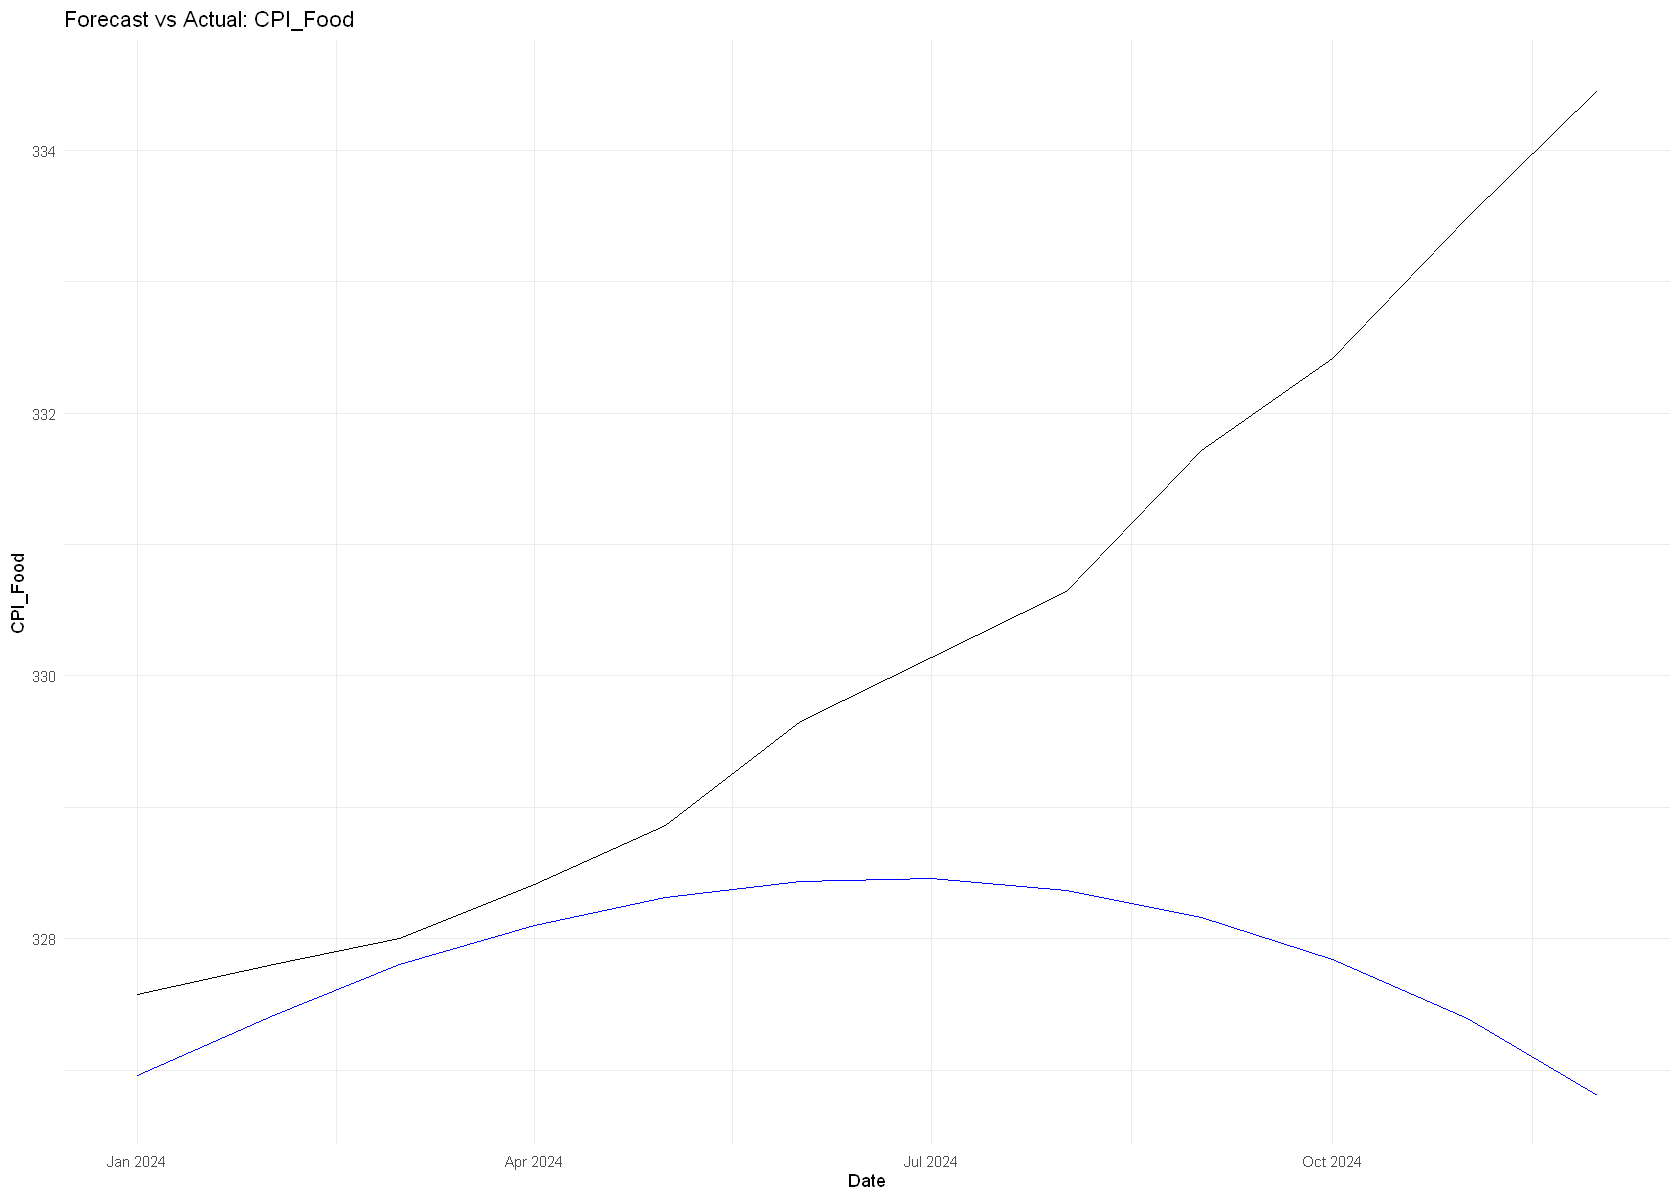

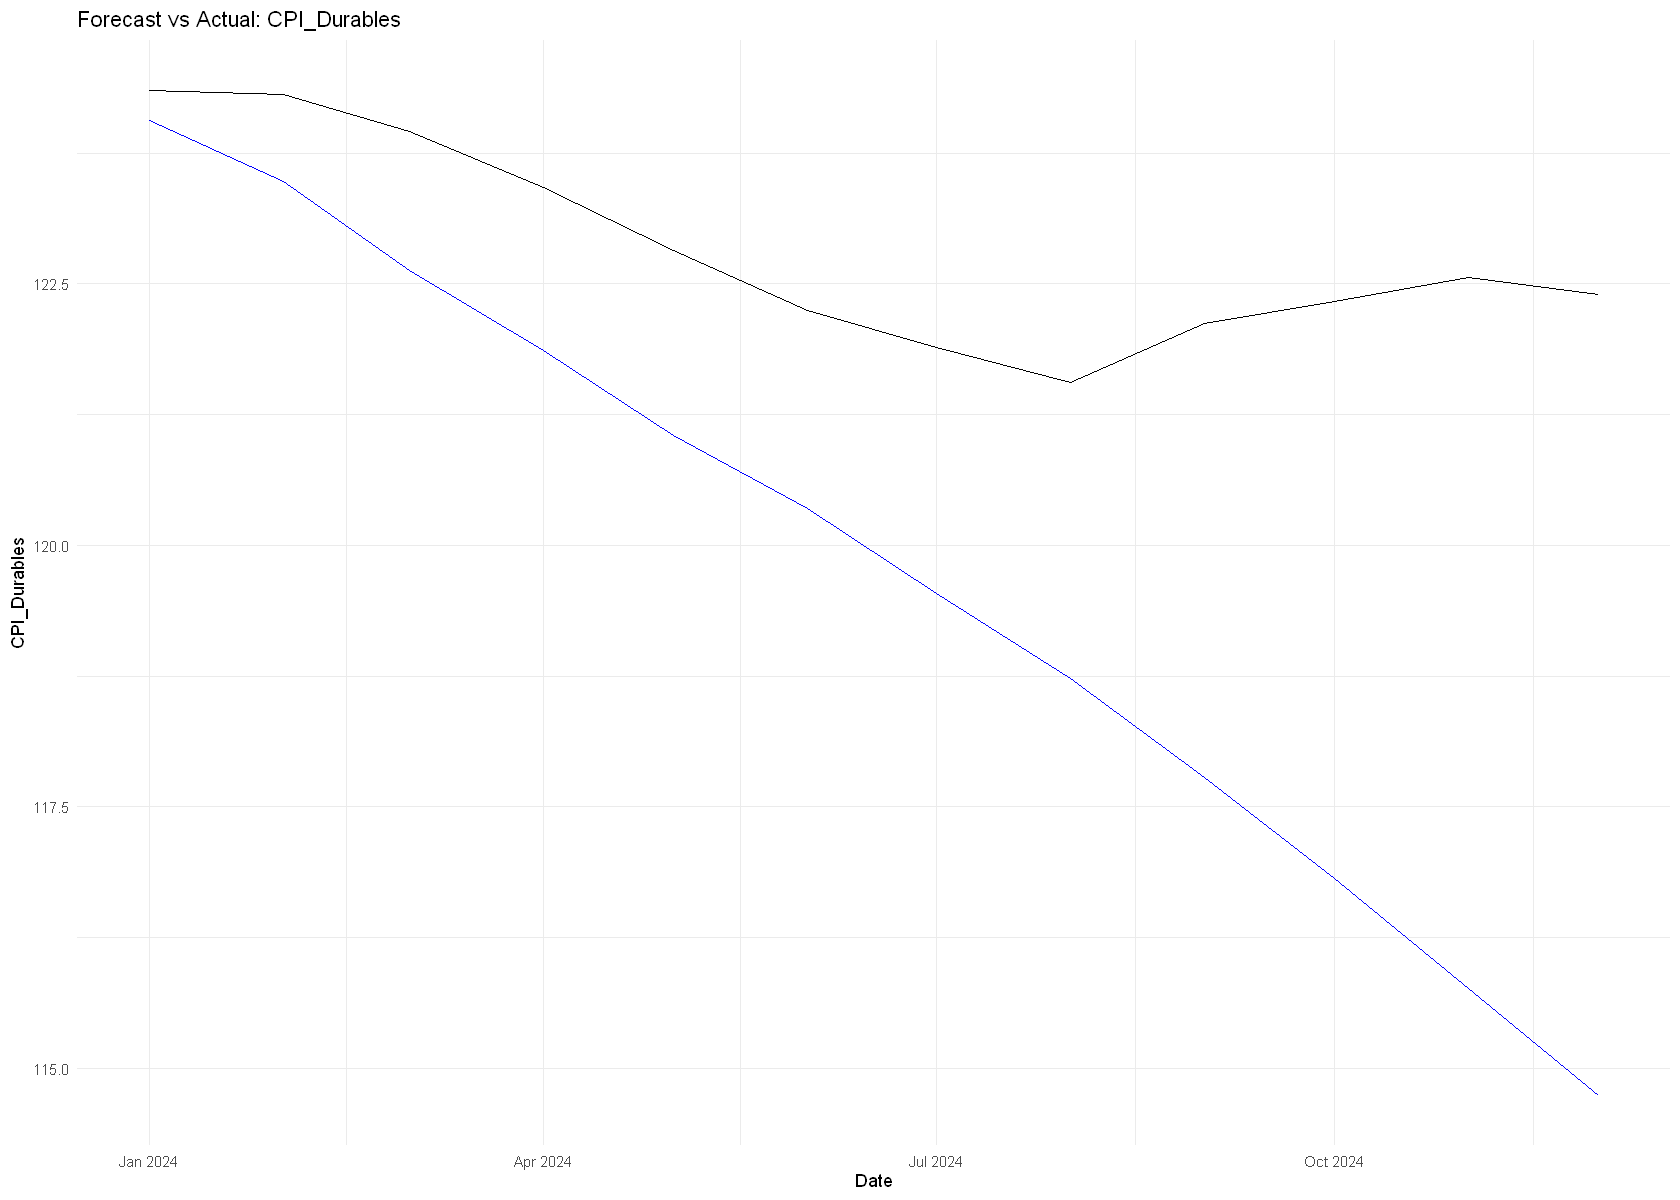

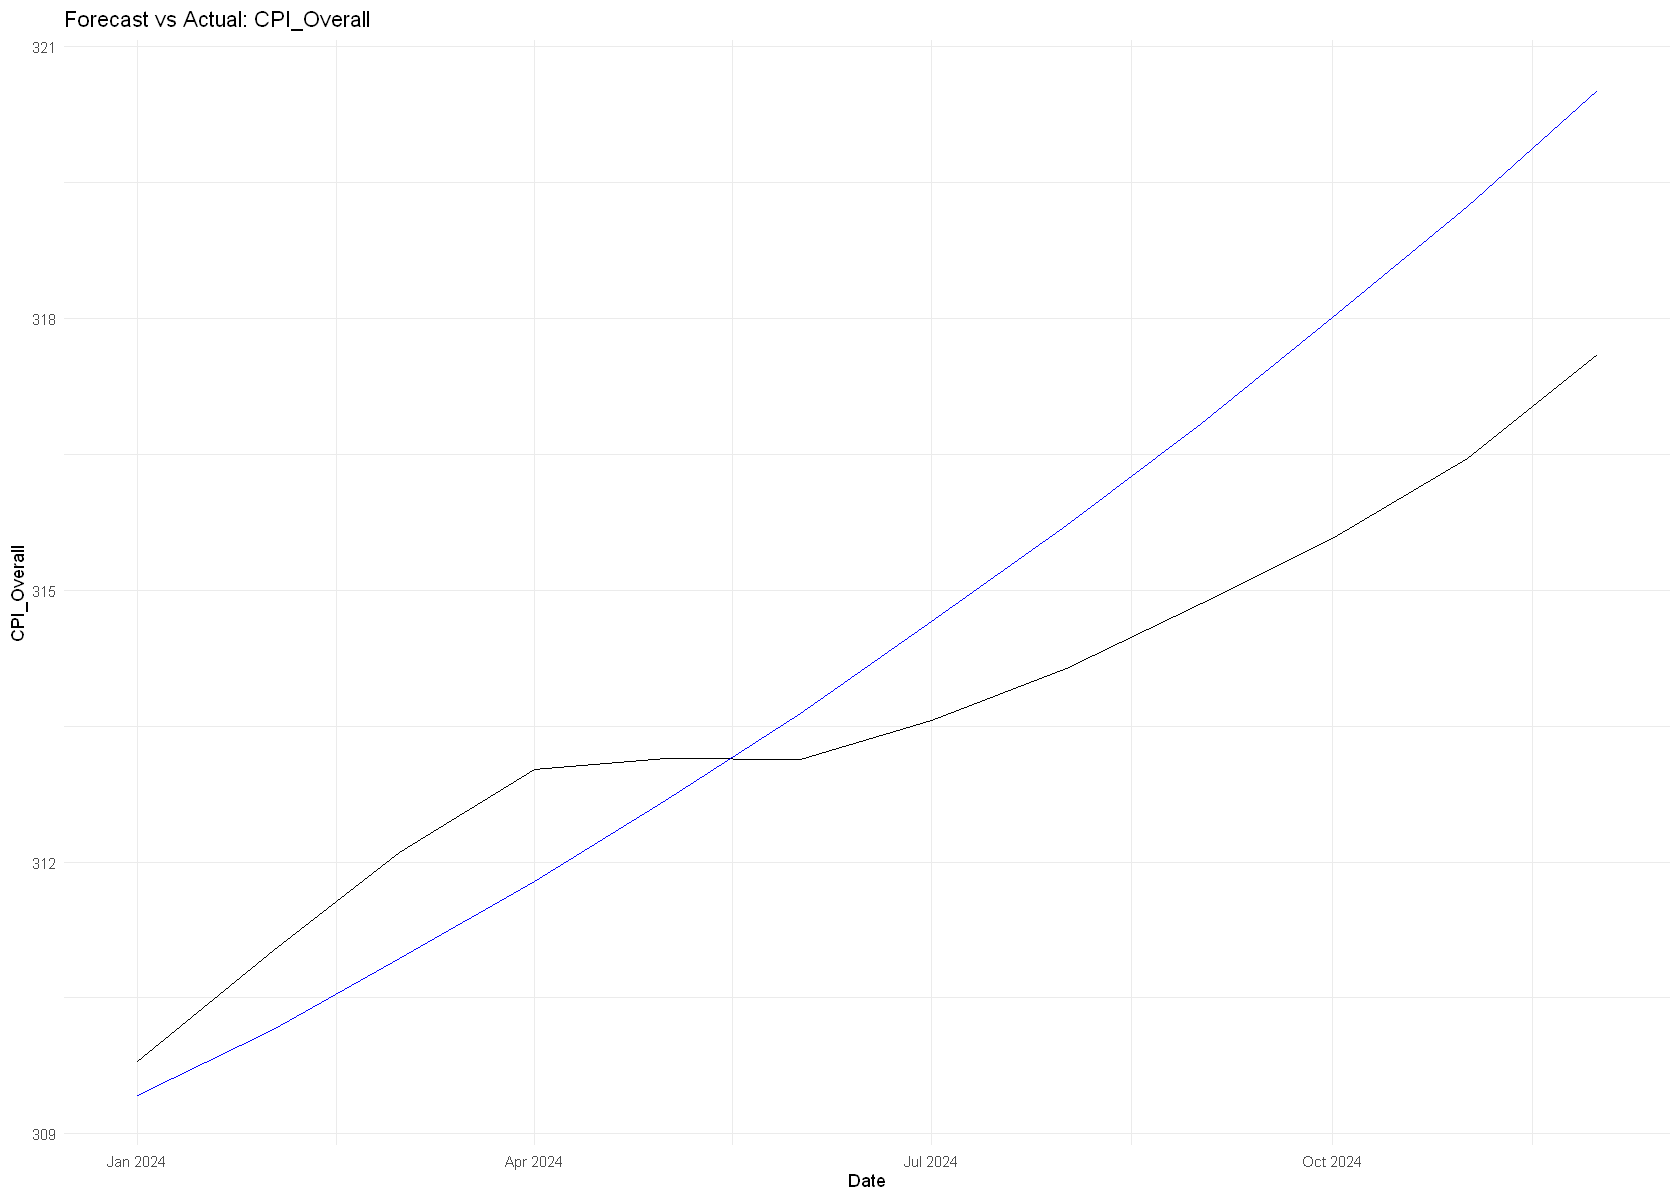

In [20]:
train_data <- filter(combined_with_tariff, Year <= 2023)
test_data  <- filter(combined_with_tariff, Year == 2024)

best_models <- list(
  dlog_CPI_Apparel     = c(0,1,2),
  d2_dlog_CPI_Food     = c(0,2,3),
  d2_dlog_CPI_Durables = c(5,2,2),
  d2_dlog_CPI_Overall  = c(0,2,4)
)

orig_series <- list(
  dlog_CPI_Apparel     = "CPI_Apparel",
  d2_dlog_CPI_Food     = "CPI_Food",
  d2_dlog_CPI_Durables = "CPI_Durables",
  d2_dlog_CPI_Overall  = "CPI_Overall"
)

forecast_results <- list()
forecast_plots <- list()

for (cpi_var in names(best_models)) {
  
  order_vals <- best_models[[cpi_var]]
  p <- order_vals[1]
  d <- order_vals[2]
  q <- order_vals[3]
  
  y_train <- train_data[[cpi_var]]
  x_train <- train_data$d_log_MFN
  valid_idx <- which(!is.na(y_train) & !is.na(x_train))
  y_train <- y_train[valid_idx]
  x_train <- x_train[valid_idx]
  
  fit <- Arima(y_train, order = c(p,d,q), xreg = x_train)
  
  x_future <- test_data$d_log_MFN
  if(length(x_future) != nrow(test_data)) x_future <- x_future[1:nrow(test_data)]
  
  fc <- forecast(fit, xreg = x_future, h = nrow(test_data))
  
  orig <- orig_series[[cpi_var]]
  
  if (grepl("^dlog_", cpi_var)) {
    last_train <- tail(train_data[[orig]][!is.na(train_data[[orig]])], 1)
    fc_point <- last_train * exp(cumsum(fc$mean))
    
  } else if (grepl("^d2_dlog_", cpi_var)) {
    first_diff_name <- sub("^d2_", "", cpi_var)
    last_dlog <- tail(train_data[[first_diff_name]][!is.na(train_data[[first_diff_name]])], 1)
    
    dlog_forecast <- last_dlog + cumsum(fc$mean)
    last_train <- tail(train_data[[orig]][!is.na(train_data[[orig]])], 1)
    fc_point <- last_train * exp(cumsum(dlog_forecast))
  }
  
  forecast_results[[cpi_var]] <- data.frame(
    Date = test_data$Date,
    Forecast = fc_point,
    Actual = test_data[[orig]]
  )
  
  p1 <- ggplot() +
    geom_line(aes(x = test_data$Date, y = test_data[[orig]]), color = "black") +
    geom_line(aes(x = test_data$Date, y = fc_point), color = "blue") +
    labs(title = paste("Forecast vs Actual:", orig),
         x = "Date", y = orig) +
    theme_minimal()
  
  print(p1)
  forecast_plots[[cpi_var]] <- p1
}


In [21]:
cpi_name_map <- c(
  dlog_CPI_Apparel     = "CPI_Apparel",
  d2_dlog_CPI_Food     = "CPI_Food",
  d2_dlog_CPI_Durables = "CPI_Durables",
  d2_dlog_CPI_Overall  = "CPI_Overall"
)

combined_forecasts <- do.call(rbind, lapply(names(forecast_results), function(cpi_var) {
  df <- forecast_results[[cpi_var]]
  df$CPI_Var <- cpi_name_map[[cpi_var]] 
  df <- df[, c("CPI_Var", "Date", "Actual", "Forecast")]
  return(df)
}))

row.names(combined_forecasts) <- NULL
print(combined_forecasts)


        CPI_Var       Date  Actual Forecast
1   CPI_Apparel 2024-01-01 129.554 130.5694
2   CPI_Apparel 2024-02-01 130.223 130.6618
3   CPI_Apparel 2024-03-01 130.962 130.7543
4   CPI_Apparel 2024-04-01 132.098 130.8468
5   CPI_Apparel 2024-05-01 131.816 130.9395
6   CPI_Apparel 2024-06-01 131.798 131.0321
7   CPI_Apparel 2024-07-01 131.448 131.1249
8   CPI_Apparel 2024-08-01 131.581 131.2177
9   CPI_Apparel 2024-09-01 132.886 131.3106
10  CPI_Apparel 2024-10-01 131.706 131.4035
11  CPI_Apparel 2024-11-01 131.814 131.4965
12  CPI_Apparel 2024-12-01 131.986 131.5896
13     CPI_Food 2024-01-01 327.575 326.9636
14     CPI_Food 2024-02-01 327.803 327.4190
15     CPI_Food 2024-03-01 328.004 327.8010
16     CPI_Food 2024-04-01 328.413 328.1028
17     CPI_Food 2024-05-01 328.864 328.3173
18     CPI_Food 2024-06-01 329.651 328.4377
19     CPI_Food 2024-07-01 330.142 328.4570
20     CPI_Food 2024-08-01 330.644 328.3686
21     CPI_Food 2024-09-01 331.716 328.1657
22     CPI_Food 2024-10-01 332.4

In [22]:
combined_table <- data.frame(Date = forecast_results[[1]]$Date)

for(cpi_var in names(forecast_results)) {
  orig_name <- cpi_name_map[[cpi_var]]
  df <- forecast_results[[cpi_var]]
  
  combined_table[[paste0(orig_name, "_Actual")]] <- df$Actual
  combined_table[[paste0(orig_name, "_Forecast")]] <- df$Forecast
}

print(combined_table)

         Date CPI_Apparel_Actual CPI_Apparel_Forecast CPI_Food_Actual
1  2024-01-01            129.554             130.5694         327.575
2  2024-02-01            130.223             130.6618         327.803
3  2024-03-01            130.962             130.7543         328.004
4  2024-04-01            132.098             130.8468         328.413
5  2024-05-01            131.816             130.9395         328.864
6  2024-06-01            131.798             131.0321         329.651
7  2024-07-01            131.448             131.1249         330.142
8  2024-08-01            131.581             131.2177         330.644
9  2024-09-01            132.886             131.3106         331.716
10 2024-10-01            131.706             131.4035         332.418
11 2024-11-01            131.814             131.4965         333.492
12 2024-12-01            131.986             131.5896         334.456
   CPI_Food_Forecast CPI_Durables_Actual CPI_Durables_Forecast
1           326.9636       

In [23]:
cpi_vars <- c("CPI_Apparel", "CPI_Food", "CPI_Durables", "CPI_Overall")

accuracy_table <- data.frame(
  CPI_Var = character(),
  RMSE = numeric(),
  MAPE = numeric(),
  Precision = numeric(),
  stringsAsFactors = FALSE
)

for (cpi in cpi_vars) {
  
  actual <- combined_table[[paste0(cpi, "_Actual")]]
  forecast <- combined_table[[paste0(cpi, "_Forecast")]]
  
  rmse_val <- rmse(actual, forecast)
  mape_val <- mape(actual, forecast) * 100
  precision_val <- mean(1 - abs(actual - forecast)/actual)
  
  accuracy_table <- rbind(accuracy_table, data.frame(
    CPI_Var = cpi,
    RMSE = round(rmse_val, 4),
    MAPE = round(mape_val, 2),
    Precision = round(precision_val, 4)
  ))
}

print(accuracy_table)


       CPI_Var   RMSE MAPE Precision
1  CPI_Apparel 0.7775 0.50    0.9950
2     CPI_Food 3.4124 0.73    0.9927
3 CPI_Durables 3.8666 2.53    0.9747
4  CPI_Overall 1.6851 0.46    0.9954


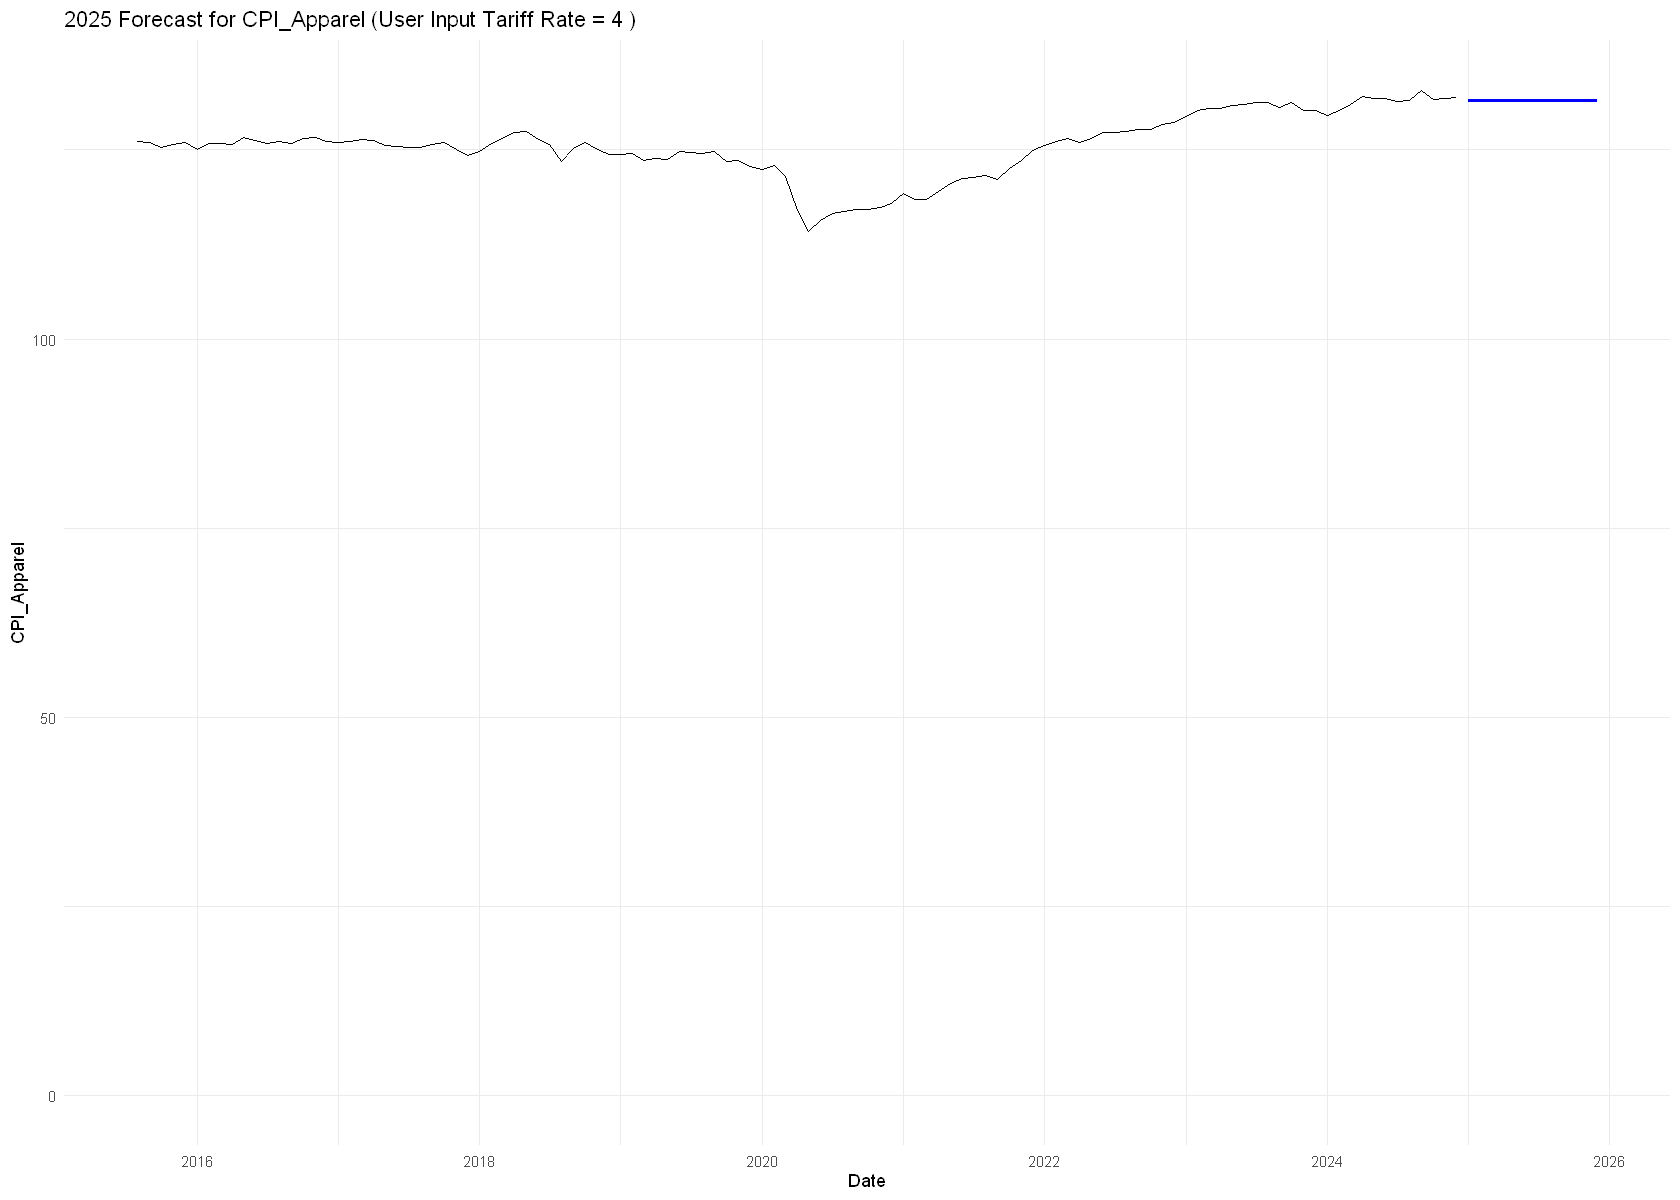

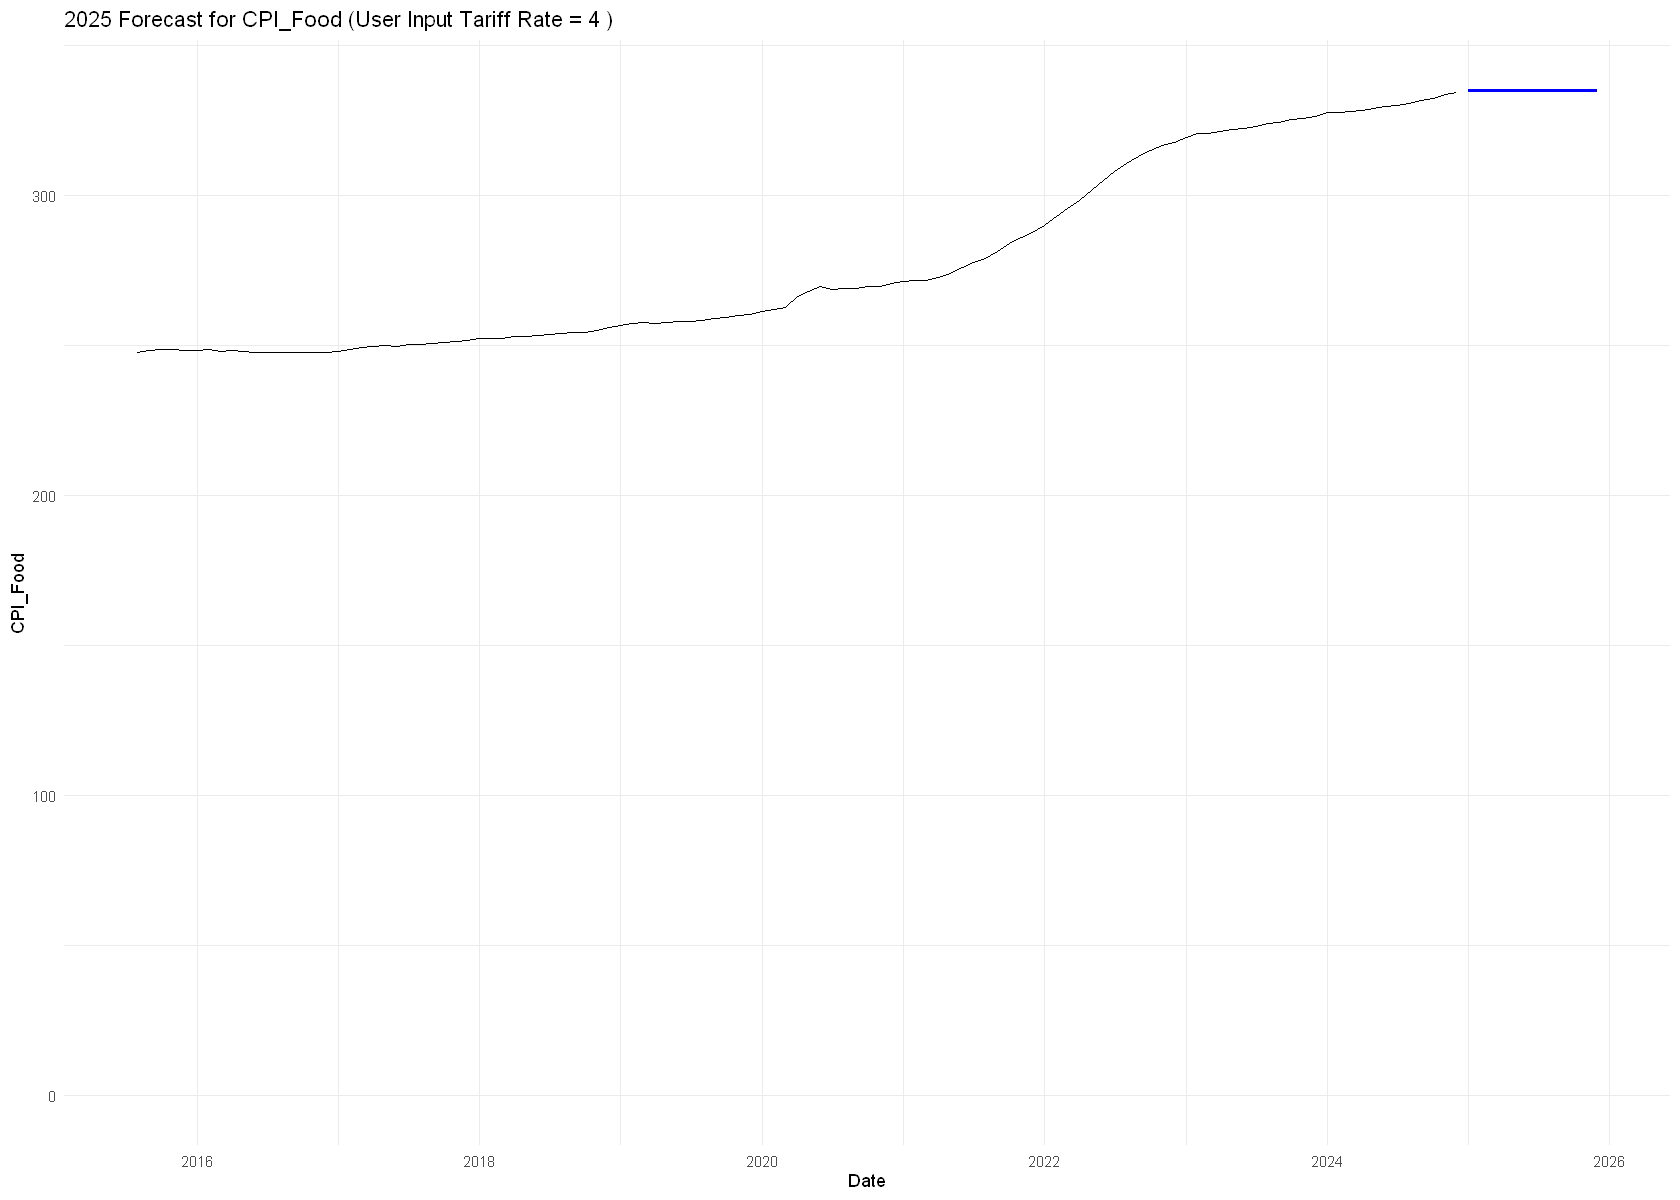

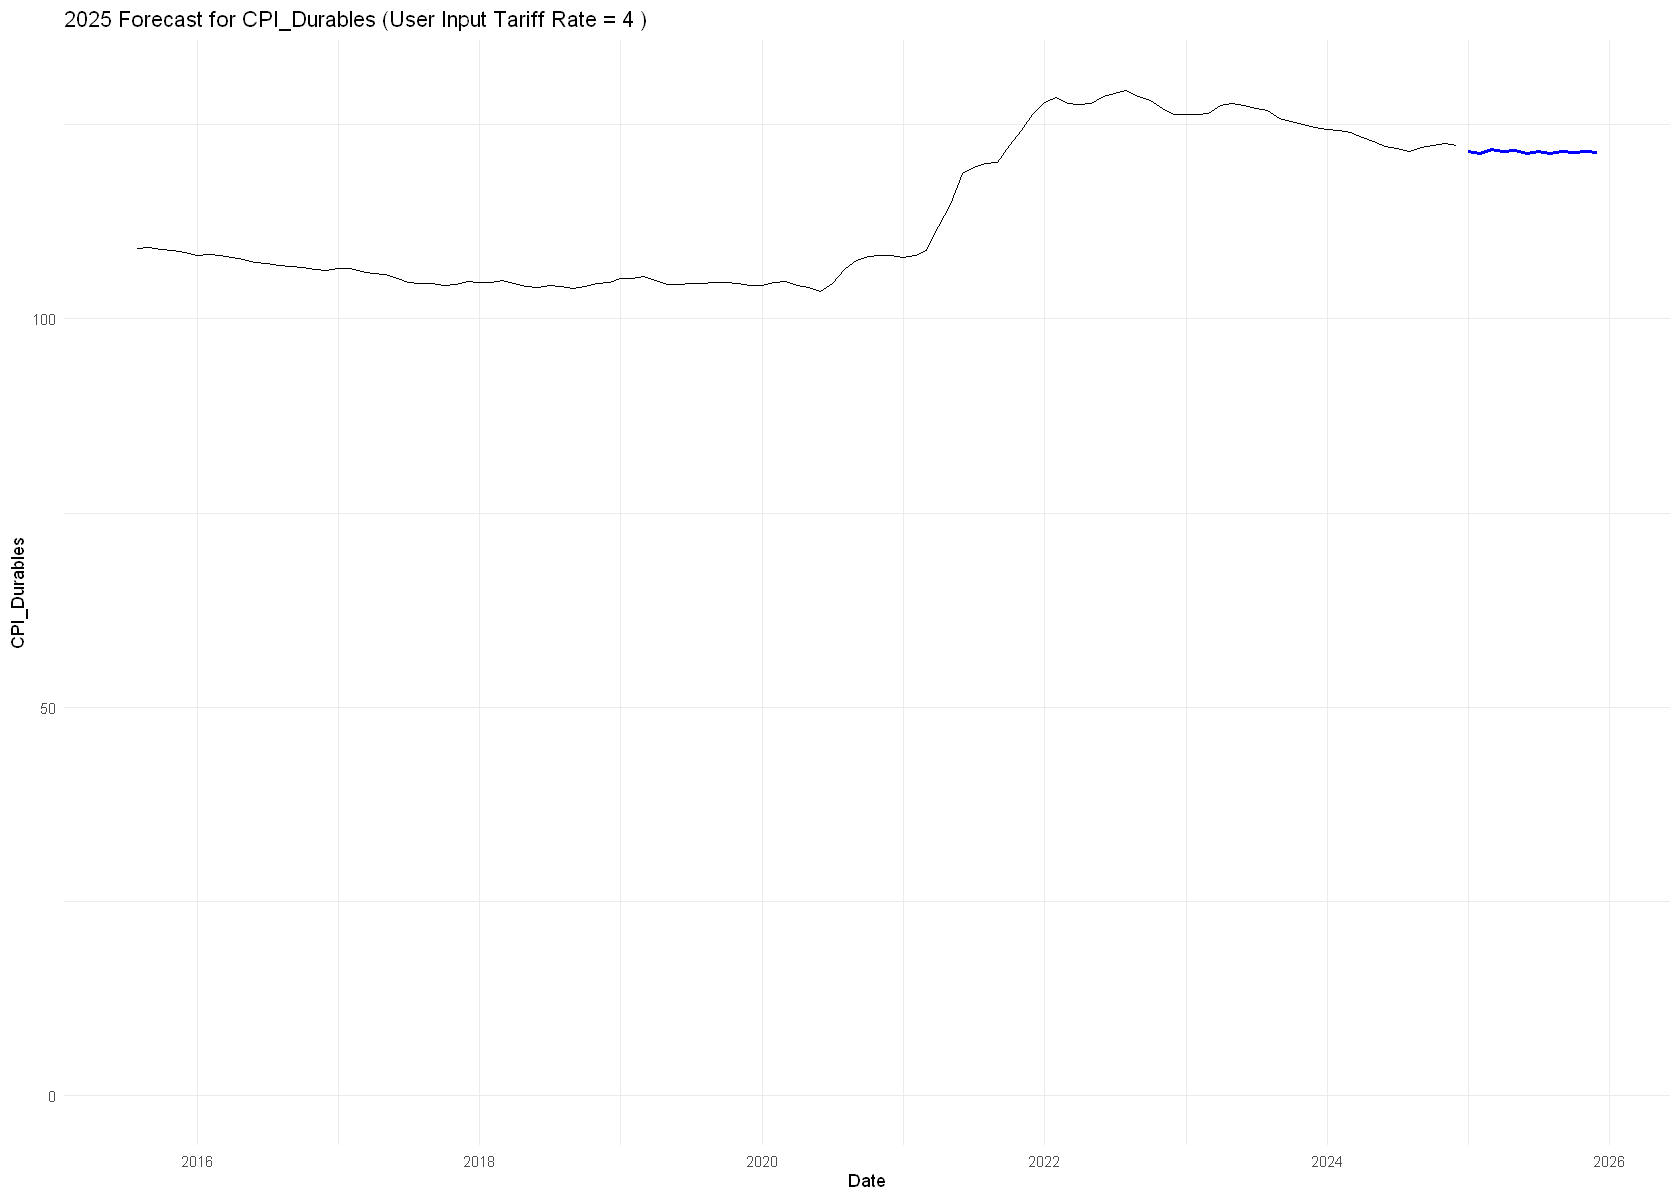

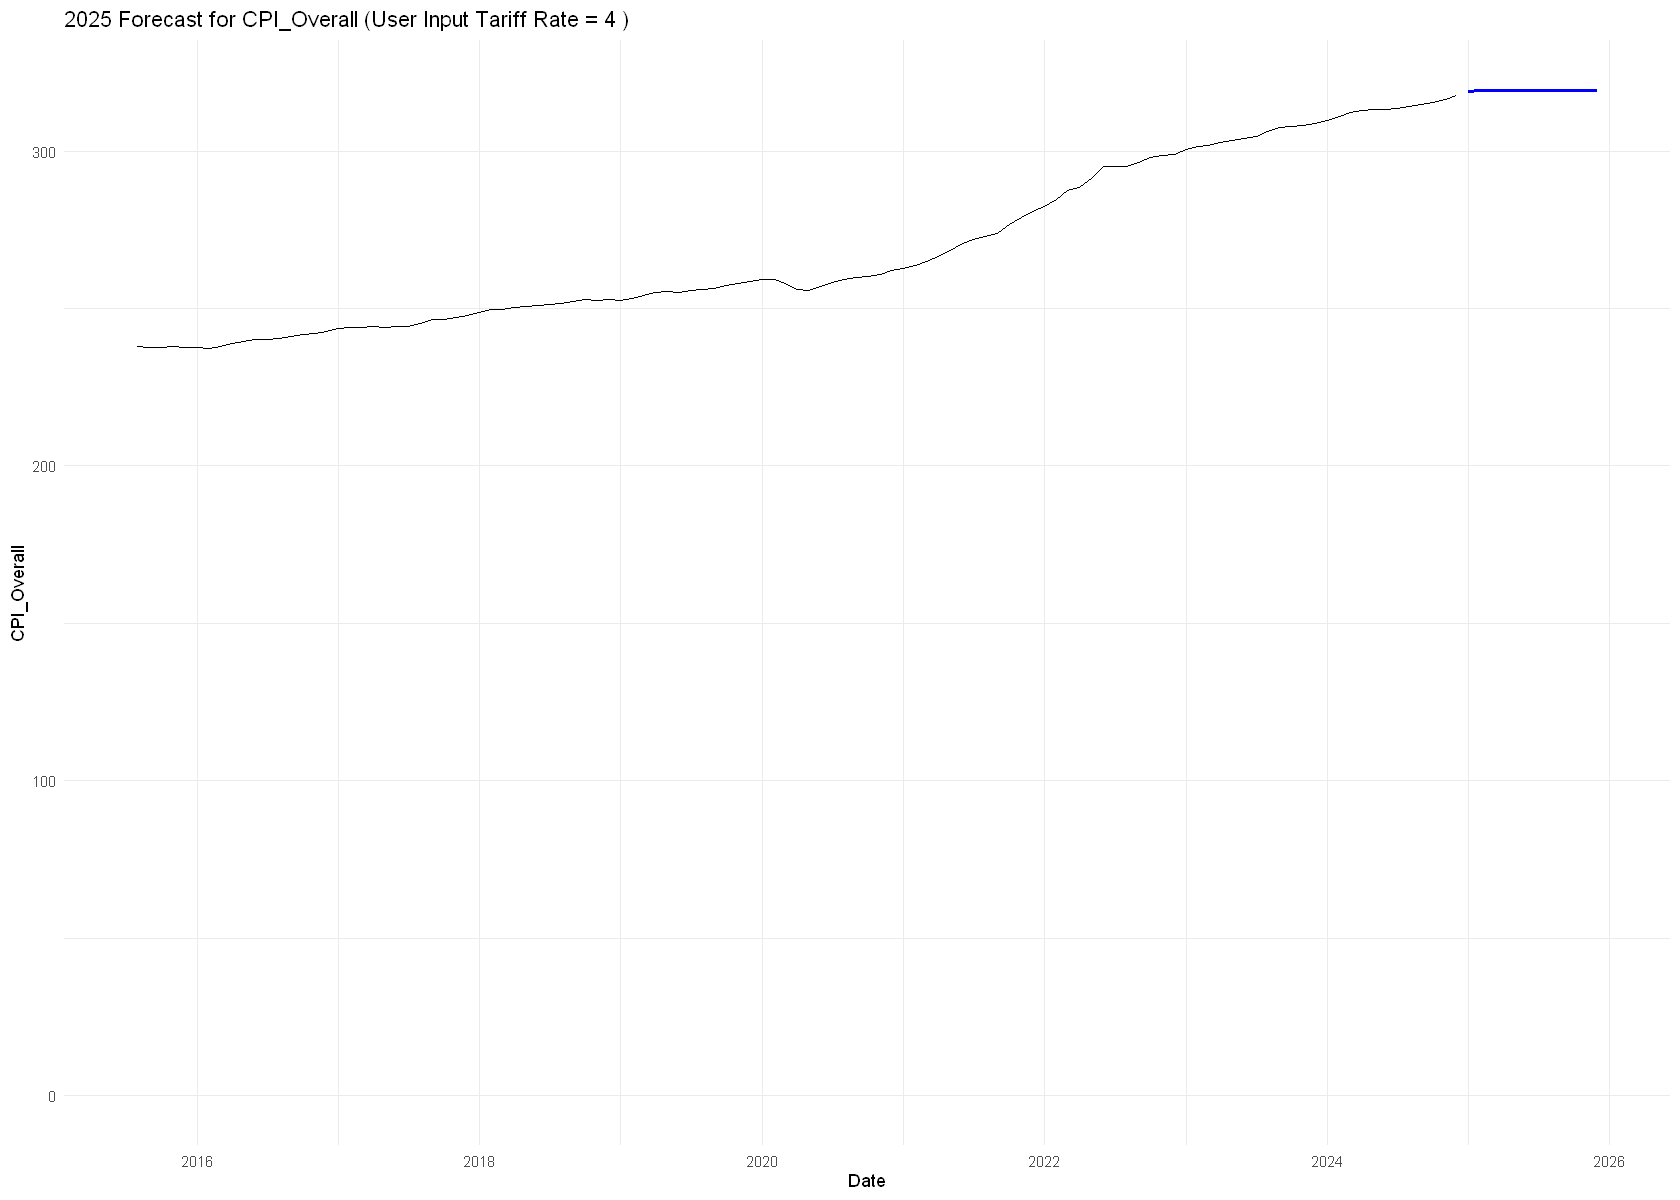

In [24]:
combined_with_tariff$MFN_Tariff <- as.numeric(as.character(combined_with_tariff$MFN_Tariff))

combined_with_tariff <- mutate(combined_with_tariff,
  log_MFN   = log(MFN_Tariff),
  d_log_MFN = c(NA, diff(log_MFN)))

best_models <- list(
  dlog_CPI_Apparel     = c(0,1,2),
  d2_dlog_CPI_Food     = c(0,2,3),
  d2_dlog_CPI_Durables = c(5,2,2),
  d2_dlog_CPI_Overall  = c(0,2,4)
)

orig_series <- list(
  dlog_CPI_Apparel     = "CPI_Apparel",
  d2_dlog_CPI_Food     = "CPI_Food",
  d2_dlog_CPI_Durables = "CPI_Durables",
  d2_dlog_CPI_Overall  = "CPI_Overall"
)

full_train <- filter(combined_with_tariff, Year <= 2024)

forecast_2025 <- list()
forecast_plots <- list()

#The below is the tariff rate which the user should be able to changed. For now im using a placeholder but need to figure out how to integrate this with the dashboard
#The previous tariff rate data point was 3.34
Tariff_2025 <- 4
last_Tariff <- tail(full_train$MFN_Tariff, 1)
d_log_Tariff_2025 <- log(Tariff_2025 / last_Tariff) 

xreg_2025 <- rep(d_log_Tariff_2025, 12)
dates_2025 <- seq(from = as.Date("2025-01-01"), by = "month", length.out = 12)

for (cpi_var in names(best_models)) {

  p <- best_models[[cpi_var]][1]
  d <- best_models[[cpi_var]][2]
  q <- best_models[[cpi_var]][3]

  y_train <- full_train[[cpi_var]]
  x_train <- full_train$d_log_MFN
  valid_idx <- which(!is.na(y_train) & !is.na(x_train))
  y_train <- y_train[valid_idx]
  x_train <- x_train[valid_idx]


  fit <- Arima(y_train, order = c(p,d,q), xreg = x_train)
  fc <- forecast(fit, xreg = xreg_2025, h = 12)
  orig <- orig_series[[cpi_var]]

  if (grepl("^dlog_", cpi_var)) {
    last_level <- tail(full_train[[orig]][!is.na(full_train[[orig]])], 1)
    fc_point <- last_level * exp(fc$mean)

  } else if (grepl("^d2_dlog_", cpi_var)) {
    first_diff_name <- sub("^d2_", "", cpi_var)
    last_dlog <- tail(full_train[[first_diff_name]][!is.na(full_train[[first_diff_name]])], 1)
    fc_point <- tail(full_train[[orig]][!is.na(full_train[[orig]])], 1) * exp(last_dlog + fc$mean)
  }

  forecast_2025[[cpi_var]] <- data.frame(
    Date = dates_2025,
    Forecast = fc_point
  )

  p1 <- ggplot() +
    geom_line(aes(x = full_train$Date, y = full_train[[orig]]),
              color = "black") +
    geom_line(aes(x = dates_2025, y = fc_point),
              color = "blue", linewidth = 1.1) +
    labs(
      title = paste("2025 Forecast for", orig, "(User Input Tariff Rate =", Tariff_2025, ")"),
      x = "Date",
      y = orig
    ) +
    theme_minimal() +
    scale_y_continuous(limits = c(0, NA))

  print(p1)
  forecast_plots[[cpi_var]] <- p1
}


In [25]:
combined_forecast_2025 <- do.call(cbind, lapply(forecast_2025, function(x) x["Forecast"]))
combined_forecast_2025 <- cbind(Date = dates_2025, combined_forecast_2025)
print(combined_forecast_2025)

         Date Forecast Forecast Forecast Forecast
1  2025-01-01 131.4772 335.0163 121.5404 319.0263
2  2025-02-01 131.5010 335.0407 121.3008 319.0867
3  2025-03-01 131.5010 335.0387 121.8094 319.2958
4  2025-04-01 131.5010 335.0367 121.5107 319.2952
5  2025-05-01 131.5010 335.0347 121.6705 319.2946
6  2025-06-01 131.5010 335.0328 121.3550 319.2941
7  2025-07-01 131.5010 335.0308 121.5091 319.2935
8  2025-08-01 131.5010 335.0288 121.3388 319.2929
9  2025-09-01 131.5010 335.0268 121.5590 319.2924
10 2025-10-01 131.5010 335.0249 121.4760 319.2918
11 2025-11-01 131.5010 335.0229 121.6139 319.2912
12 2025-12-01 131.5010 335.0209 121.4810 319.2907


Ran into these issues (Can mention in uses faced or sth similar in conclusion):

The data was not stationary so it had to be first transformed using log and then for forecasting it had to be changed back.. due to this there were exponential increases in the forecast if the tariff rate was different than the previous ones. To address this the tariff rate input is scaled to the previous tariff rate. 
This fixed the issue however it reduced the influence of the tariff affecting the CPI
However: 0 Tariff doesnt work (because of the logs involved)

Also due to the use of exponential to tranform back from log the confidence band values were getting exponentially increased so i removed the confidence bands.
PPI forecast was abandoned to the same issue of nonstationarity and the need for multiple order differencing + log transforms

Issues and possible fixes (for future reference in report)
Granuality of data: we found monthly CPI data however, the tariff data was yearly (So for the purpose of forecasting the same tariff value was assumed for every month in a year) This may not reflect real life tariff change.
Non stationarity being an issue: had to tranform the data to make it stationary first (this is a key assumption for ARIMA modelling)
Alternate models such as VAR or VARX may be better for forecasting (sadly I learnt these models now)
Using machine learning models such as Prophet or Silverkite may have better results (I have not learnt these yet so couldnt not implement it)

In [26]:
#Code for different tariff rates 1-100 in increments if 0.5.
combined_with_tariff$MFN_Tariff <- as.numeric(as.character(combined_with_tariff$MFN_Tariff))

combined_with_tariff <- mutate(combined_with_tariff,
  log_MFN   = log(MFN_Tariff),
  d_log_MFN = c(NA, diff(log_MFN))
)

best_models <- list(
  dlog_CPI_Apparel     = c(0,1,2),
  d2_dlog_CPI_Food     = c(0,2,3),
  d2_dlog_CPI_Durables = c(5,2,2),
  d2_dlog_CPI_Overall  = c(0,2,4)
)

orig_series <- list(
  dlog_CPI_Apparel     = "CPI_Apparel",
  d2_dlog_CPI_Food     = "CPI_Food",
  d2_dlog_CPI_Durables = "CPI_Durables",
  d2_dlog_CPI_Overall  = "CPI_Overall"
)

full_train <- filter(combined_with_tariff, Year <= 2024)
dates_2025 <- seq(from = as.Date("2025-01-01"), by = "month", length.out = 12)

forecast_table <- data.frame()

tariff_values <- seq(1, 100, by = 0.5)

for (Tariff_2025 in tariff_values) {

  last_Tariff <- tail(full_train$MFN_Tariff, 1)
  d_log_Tariff_2025 <- log(Tariff_2025 / last_Tariff)

  xreg_2025 <- rep(d_log_Tariff_2025, 12)

  for (cpi_var in names(best_models)) {

    p <- best_models[[cpi_var]][1]
    d <- best_models[[cpi_var]][2]
    q <- best_models[[cpi_var]][3]

    y_train <- full_train[[cpi_var]]
    x_train <- full_train$d_log_MFN

    valid_idx <- which(!is.na(y_train) & !is.na(x_train))
    y_train <- y_train[valid_idx]
    x_train <- x_train[valid_idx]

    fit <- Arima(y_train, order = c(p,d,q), xreg = x_train)
    fc <- forecast(fit, xreg = xreg_2025, h = 12)
    orig <- orig_series[[cpi_var]]

    if (grepl("^dlog_", cpi_var)) {

      last_level <- tail(full_train[[orig]][!is.na(full_train[[orig]])], 1)
      fc_point <- last_level * exp(fc$mean)

    } else if (grepl("^d2_dlog_", cpi_var)) {

      first_diff_name <- sub("^d2_", "", cpi_var)
      last_dlog <- tail(full_train[[first_diff_name]][!is.na(full_train[[first_diff_name]])], 1)
      last_level <- tail(full_train[[orig]][!is.na(full_train[[orig]])], 1)

      fc_point <- last_level * exp(last_dlog + fc$mean)
    }

    forecast_table <- rbind(
      forecast_table,
      data.frame(
        Date = dates_2025,
        Industry = orig,
        Tariff_Rate = Tariff_2025,
        CPI_Forecast = as.numeric(fc_point)
      )
    )
  }
}

In [31]:
forecast_table$Industry <- recode(forecast_table$Industry,"CPI_Apparel" = "CPI Apparel")
forecast_table$Industry <- recode(forecast_table$Industry,"CPI_Food" = "CPI Food")
forecast_table$Industry <- recode(forecast_table$Industry,"CPI_Durables" = "CPI Electronics")
forecast_table$Industry <- recode(forecast_table$Industry,"CPI_Overall" = "CPI Overall")
head(forecast_table,25)
write.csv(forecast_table, "CPI_Forecast_TariffScenarios.csv", row.names = FALSE)

,Date,Industry,Tariff_Rate,CPI_Forecast
,<date>,<chr>,<dbl>,<dbl>
1,2025-01-01,CPI Apparel,1,135.9967
2,2025-02-01,CPI Apparel,1,136.0213
3,2025-03-01,CPI Apparel,1,136.0213
4,2025-04-01,CPI Apparel,1,136.0213
5,2025-05-01,CPI Apparel,1,136.0213
6,2025-06-01,CPI Apparel,1,136.0213
7,2025-07-01,CPI Apparel,1,136.0213
8,2025-08-01,CPI Apparel,1,136.0213
9,2025-09-01,CPI Apparel,1,136.0213
